In [1]:
# ============================================================
# LBP–GLCM–PCA–SVM MODEL FOR SA210 GRADE A1 MICROSTRUCTURE
# Final GitHub-ready notebook version
# ============================================================
# -----------------------------
# 1. Import libraries
# -----------------------------
import os
import re
import time
import json
import joblib
import platform
import warnings
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import local_binary_pattern

try:
    from skimage.feature import graycomatrix, graycoprops
except ImportError:
    from skimage.feature import greycomatrix as graycomatrix
    from skimage.feature import greycoprops as graycoprops

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    GroupShuffleSplit
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    precision_recall_fscore_support,
    f1_score
)
from sklearn.utils import shuffle

warnings.filterwarnings("ignore", category=UserWarning)

# -----------------------------
# 2. Global configuration
# -----------------------------
DATA_DIR = Path("SA210A1")
VALIDATION_DIR = Path("Validasi_SA210A1")

OUTPUT_DIR = Path("results")
MODEL_DIR = Path("models")
FEATURE_DIR = Path("features")

for d in [OUTPUT_DIR, MODEL_DIR, FEATURE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (256, 256)

# LBP settings
RADII = [1, 2, 3]
LBP_METHOD = "uniform"

# GLCM settings
GLCM_DISTANCES = [1, 2, 3]
GLCM_ANGLES = [0, np.pi/4, np.pi/2, 3*np.pi/4]
GLCM_LEVELS = 64
GLCM_PROPERTIES = [
    "contrast",
    "dissimilarity",
    "homogeneity",
    "energy",
    "entropy",
    "correlation"
]

# Preprocessing settings
USE_CLAHE = True
CLAHE_CLIP = 2.0
CLAHE_GRID = (8, 8)

# IMPORTANT:
# Set True if your images contain a scale bar or annotation at the bottom.
# This same setting is applied to training, testing, and validation images.
CROP_SCALEBAR = True
CROP_RATIO = 0.90

# Model settings
RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
N_JOBS = -1
ENABLE_PROBABILITY = False

# Final model setting
FINAL_PCA_COMPONENTS = 50

# Optional:
# Use group-based split only if filenames contain a reliable sample/micrograph ID.
# For example: "S01_img001.png", "S01_img002.png", "S02_img001.png".
USE_GROUP_SPLIT = False

VALID_EXTENSIONS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

CLASS_NAMES = ["StageA", "StageB", "StageC", "StageD", "StageE", "StageF"]

MODEL_PATH = MODEL_DIR / f"model_lbp_glcm_pca{FINAL_PCA_COMPONENTS}_svm_final.pkl"

print("Configuration loaded.")
print("Python:", platform.python_version())
print("OpenCV:", cv2.__version__)
print("Final model path:", MODEL_PATH)

Configuration loaded.
Python: 3.10.11
OpenCV: 4.12.0
Final model path: models\model_lbp_glcm_pca50_svm_final.pkl


In [2]:
# ============================================================
# Utility functions and preprocessing
# ============================================================

def list_image_files(data_dir, class_names=None):
    """
    Read image paths and labels from a directory structure:
    data_dir/
        StageA/
        StageB/
        ...
    """
    data_dir = Path(data_dir)

    if not data_dir.exists():
        raise FileNotFoundError(f"Data directory not found: {data_dir}")

    if class_names is None:
        class_names = sorted([p.name for p in data_dir.iterdir() if p.is_dir()])

    filepaths = []
    labels = []
    skipped_folders = []

    for cls in class_names:
        folder = data_dir / cls

        if not folder.is_dir():
            skipped_folders.append(str(folder))
            continue

        for f in sorted(folder.iterdir()):
            if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS:
                filepaths.append(str(f))
                labels.append(cls)

    if skipped_folders:
        print("[WARNING] Missing folders:")
        for f in skipped_folders:
            print(" -", f)

    return np.array(filepaths), np.array(labels)


def summarize_dataset(data_dir, class_names=None, title="Dataset summary"):
    """
    Summarize the number of images in each class folder.
    """
    filepaths, labels = list_image_files(data_dir, class_names)
    counts = Counter(labels)
    total = len(labels)

    print("\n" + "="*60)
    print(title)
    print("="*60)
    print(f"Directory: {data_dir}")
    print(f"Total images: {total}")

    for cls in sorted(counts.keys()):
        pct = 100 * counts[cls] / total if total > 0 else 0
        print(f"{cls:10s}: {counts[cls]:4d} images ({pct:6.2f}%)")

    summary_df = pd.DataFrame({
        "Class": list(counts.keys()),
        "Count": list(counts.values()),
        "Percentage": [100 * counts[c] / total for c in counts.keys()]
    }).sort_values("Class")

    return summary_df


def apply_clahe(gray_img):
    """
    Apply Contrast-Limited Adaptive Histogram Equalization.
    """
    clahe = cv2.createCLAHE(
        clipLimit=CLAHE_CLIP,
        tileGridSize=CLAHE_GRID
    )
    return clahe.apply(gray_img)


def crop_remove_scalebar(gray_img, crop_ratio=0.90):
    """
    Remove the lower part of the image where the scale bar is usually located.
    The same crop must be applied to training, testing, and validation images.
    """
    h, w = gray_img.shape
    h_crop = int(h * crop_ratio)

    if h_crop <= 1:
        return gray_img

    return gray_img[:h_crop, :]


def preprocess_image_file(image_path):
    """
    Complete preprocessing pipeline.
    This function is used consistently for training, testing, and validation.
    """
    img = cv2.imread(str(image_path))

    if img is None:
        raise ValueError(f"Cannot read image: {image_path}")

    if img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img.copy()

    if CROP_SCALEBAR:
        gray = crop_remove_scalebar(gray, crop_ratio=CROP_RATIO)

    gray = cv2.resize(
        gray,
        IMG_SIZE,
        interpolation=cv2.INTER_AREA
    )

    if USE_CLAHE:
        gray = apply_clahe(gray)

    return gray


def infer_group_id(filepath):
    """
    Optional helper for group-based splitting.
    Edit this function if filenames contain specimen or micrograph IDs.

    Default behavior:
    take the first token before '_' from the filename.

    Example:
        S01_img001.png -> group ID = S01
    """
    stem = Path(filepath).stem
    return stem.split("_")[0]

In [3]:
# ============================================================
# Feature extraction functions
# ============================================================

def quantize_image(gray_img, levels=64):
    """
    Quantize an 8-bit grayscale image into the selected number of gray levels.
    """
    gray_img = np.asarray(gray_img, dtype=np.uint8)

    q = np.floor(
        gray_img.astype(np.float32) / (256 / levels)
    ).astype(np.uint8)

    q[q >= levels] = levels - 1

    return q


def extract_lbp_features(gray_img):
    """
    Multi-scale uniform LBP.

    R = 1, 2, 3 and P = 8R.

    Feature count:
    R = 1 -> P = 8  -> P + 2 = 10
    R = 2 -> P = 16 -> P + 2 = 18
    R = 3 -> P = 24 -> P + 2 = 26

    Total LBP features = 10 + 18 + 26 = 54.
    """
    lbp_features = []

    for R in RADII:
        P = 8 * R

        lbp = local_binary_pattern(
            gray_img,
            P=P,
            R=R,
            method=LBP_METHOD
        )

        bins = P + 2

        hist, _ = np.histogram(
            lbp.ravel(),
            bins=np.arange(0, bins + 1),
            range=(0, bins)
        )

        hist = hist.astype(np.float32)
        hist /= (hist.sum() + 1e-12)

        lbp_features.append(hist)

    return np.hstack(lbp_features).astype(np.float32)


def extract_glcm_features(gray_img):
    """
    Multi-distance and multi-direction GLCM features.

    Distances:
        1, 2, and 3 pixels.

    Angles:
        0°, 45°, 90°, and 135°.

    Six properties are extracted for each distance-angle pair:
        contrast,
        dissimilarity,
        homogeneity,
        energy,
        entropy,
        correlation.

    Feature count:
        3 distances × 4 angles × 6 properties = 72.
    """
    gray_q = quantize_image(gray_img, levels=GLCM_LEVELS)

    glcm = graycomatrix(
        gray_q,
        distances=GLCM_DISTANCES,
        angles=GLCM_ANGLES,
        levels=GLCM_LEVELS,
        symmetric=False,
        normed=True
    )

    contrast = graycoprops(glcm, "contrast").ravel()
    dissimilarity = graycoprops(glcm, "dissimilarity").ravel()
    homogeneity = graycoprops(glcm, "homogeneity").ravel()
    energy = graycoprops(glcm, "energy").ravel()
    correlation = graycoprops(glcm, "correlation").ravel()

    entropy_values = []

    for d_idx in range(len(GLCM_DISTANCES)):
        for a_idx in range(len(GLCM_ANGLES)):
            M = glcm[:, :, d_idx, a_idx]
            entropy = -np.sum(M * np.log(M + 1e-12))
            entropy_values.append(entropy)

    entropy = np.array(entropy_values)

    ordered_features = []

    for i in range(len(contrast)):
        ordered_features.extend([
            contrast[i],
            dissimilarity[i],
            homogeneity[i],
            energy[i],
            entropy[i],
            correlation[i]
        ])

    return np.array(ordered_features, dtype=np.float32)


def extract_lbp_glcm_features(gray_img):
    """
    Combine LBP and GLCM features into one feature vector.
    """
    lbp = extract_lbp_features(gray_img)
    glcm = extract_glcm_features(gray_img)

    return np.hstack([lbp, glcm]).astype(np.float32)


# Feature index information
LBP_FEATURE_COUNT = sum([(8 * R) + 2 for R in RADII])
GLCM_FEATURE_COUNT = len(GLCM_DISTANCES) * len(GLCM_ANGLES) * len(GLCM_PROPERTIES)
TOTAL_FEATURE_COUNT = LBP_FEATURE_COUNT + GLCM_FEATURE_COUNT

print("\nFeature configuration:")
print("LBP features :", LBP_FEATURE_COUNT)
print("GLCM features:", GLCM_FEATURE_COUNT)
print("Total features:", TOTAL_FEATURE_COUNT)


Feature configuration:
LBP features : 54
GLCM features: 72
Total features: 126


In [4]:
# ============================================================
# Dataset summary
# ============================================================

train_summary = summarize_dataset(
    DATA_DIR,
    CLASS_NAMES,
    title="Training-testing dataset summary"
)

train_summary.to_csv(
    OUTPUT_DIR / "training_dataset_summary.csv",
    index=False
)

if VALIDATION_DIR.exists():
    val_summary = summarize_dataset(
        VALIDATION_DIR,
        CLASS_NAMES,
        title="Independent validation dataset summary"
    )

    val_summary.to_csv(
        OUTPUT_DIR / "validation_dataset_summary.csv",
        index=False
    )
else:
    print(f"\n[INFO] Independent validation directory not found: {VALIDATION_DIR}")


Training-testing dataset summary
Directory: SA210A1
Total images: 1666
StageA    :  283 images ( 16.99%)
StageB    :  284 images ( 17.05%)
StageC    :  272 images ( 16.33%)
StageD    :  272 images ( 16.33%)
StageE    :  283 images ( 16.99%)
StageF    :  272 images ( 16.33%)

Independent validation dataset summary
Directory: Validasi_SA210A1
Total images: 32
StageA    :    5 images ( 15.62%)
StageB    :    5 images ( 15.62%)
StageC    :    6 images ( 18.75%)
StageD    :    5 images ( 15.62%)
StageE    :    5 images ( 15.62%)
StageF    :    6 images ( 18.75%)


In [5]:
# ============================================================
# Feature extraction with caching
# ============================================================

FEATURE_CACHE = FEATURE_DIR / "features_lbp_glcm_training.npz"


def build_feature_matrix(data_dir, class_names, cache_path=None, use_cache=True):
    """
    Build X, y, and filepaths from images.

    If cache exists, the feature matrix is loaded to save time.
    Set use_cache=False when preprocessing settings are changed.
    """
    if cache_path is not None:
        cache_path = Path(cache_path)

    if use_cache and cache_path is not None and cache_path.exists():
        print(f"\n[OK] Loading cached features from: {cache_path}")
        cached = np.load(cache_path, allow_pickle=True)

        X = cached["X"]
        y = cached["y"]
        filepaths = cached["filepaths"]

        return X, y, filepaths

    filepaths, labels = list_image_files(data_dir, class_names)
    filepaths, labels = shuffle(
        filepaths,
        labels,
        random_state=RANDOM_STATE
    )

    X_list = []
    y_list = []
    kept_paths = []
    skipped = []

    t0 = time.time()

    for idx, (fpath, label) in enumerate(zip(filepaths, labels), start=1):
        try:
            gray = preprocess_image_file(fpath)
            feat = extract_lbp_glcm_features(gray)

            if feat.shape[0] != TOTAL_FEATURE_COUNT:
                raise ValueError(f"Unexpected feature count: {feat.shape[0]}")

            X_list.append(feat)
            y_list.append(label)
            kept_paths.append(fpath)

        except Exception as e:
            skipped.append((fpath, str(e)))

        if idx % 200 == 0:
            print(f"Processed {idx}/{len(filepaths)} images")

    X = np.vstack(X_list).astype(np.float32)
    y = np.array(y_list)
    kept_paths = np.array(kept_paths)

    elapsed = time.time() - t0

    print("\nFeature extraction completed.")
    print("Feature matrix:", X.shape)
    print("Labels:", sorted(np.unique(y)))
    print(f"Elapsed time: {elapsed/60:.2f} min")

    if skipped:
        print(f"\n[WARNING] Skipped files: {len(skipped)}")

        skipped_df = pd.DataFrame(
            skipped,
            columns=["filepath", "reason"]
        )

        skipped_df.to_csv(
            OUTPUT_DIR / "skipped_training_files.csv",
            index=False
        )

    if cache_path is not None:
        np.savez_compressed(
            cache_path,
            X=X,
            y=y,
            filepaths=kept_paths
        )

        print(f"[OK] Features saved to: {cache_path}")

    return X, y, kept_paths


X, y, filepaths = build_feature_matrix(
    DATA_DIR,
    CLASS_NAMES,
    cache_path=FEATURE_CACHE,
    use_cache=True
)

print("\nFinal loaded data:")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("filepaths:", len(filepaths))


[OK] Loading cached features from: features\features_lbp_glcm_training.npz

Final loaded data:
X shape: (1665, 126)
y shape: (1665,)
filepaths: 1665


In [6]:
# ============================================================
# Train-test split
# ============================================================

if USE_GROUP_SPLIT:
    groups = np.array([infer_group_id(fp) for fp in filepaths])

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    train_idx, test_idx = next(
        splitter.split(X, y, groups=groups)
    )

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    fp_train, fp_test = filepaths[train_idx], filepaths[test_idx]

    print("\n[INFO] Group-based split was used.")
    print("Number of training groups:", len(np.unique(groups[train_idx])))
    print("Number of testing groups :", len(np.unique(groups[test_idx])))

else:
    X_train, X_test, y_train, y_test, fp_train, fp_test = train_test_split(
        X,
        y,
        filepaths,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE
    )

    print("\n[INFO] Stratified random split was used.")

split_info = pd.DataFrame({
    "filepath": np.concatenate([fp_train, fp_test]),
    "label": np.concatenate([y_train, y_test]),
    "split": ["train"] * len(fp_train) + ["test"] * len(fp_test)
})

split_info.to_csv(
    OUTPUT_DIR / "train_test_split_filepaths.csv",
    index=False
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])
print("Feature count   :", X_train.shape[1])

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts().sort_index())


[INFO] Stratified random split was used.
Training samples: 1332
Testing samples : 333
Feature count   : 126

Training class distribution:
StageA    226
StageB    227
StageC    218
StageD    218
StageE    226
StageF    217
Name: count, dtype: int64

Testing class distribution:
StageA    57
StageB    57
StageC    54
StageD    54
StageE    57
StageF    54
Name: count, dtype: int64


In [7]:
# ============================================================
# Final model training: LBP + GLCM + PCA-50 + RBF-SVM
# ============================================================

pipe_final = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(
        n_components=FINAL_PCA_COMPONENTS,
        svd_solver="full"
    )),
    ("svc", SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=ENABLE_PROBABILITY,
        random_state=RANDOM_STATE
    ))
])

param_grid_final = {
    "svc__C": [0.1, 1, 10, 50, 100],
    "svc__gamma": [0.001, 0.01, 0.1, "scale"]
}

cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

grid_final = GridSearchCV(
    estimator=pipe_final,
    param_grid=param_grid_final,
    scoring="accuracy",
    cv=cv,
    n_jobs=N_JOBS,
    verbose=2,
    return_train_score=True
)

print("\n" + "="*60)
print(f"Running GridSearchCV: LBP + GLCM + PCA-{FINAL_PCA_COMPONENTS} + RBF-SVM")
print("="*60)

t0 = time.time()

grid_final.fit(X_train, y_train)

elapsed = (time.time() - t0) / 60

best_model = grid_final.best_estimator_
best_index = grid_final.best_index_

cv_results_final = pd.DataFrame(grid_final.cv_results_)

cv_results_final.to_csv(
    OUTPUT_DIR / f"cv_results_pca{FINAL_PCA_COMPONENTS}.csv",
    index=False
)

print("\nGridSearch completed.")
print(f"Elapsed time: {elapsed:.2f} min")
print("Best parameters:", grid_final.best_params_)
print(f"Best CV accuracy: {grid_final.best_score_:.6f}")
print(f"CV std at best: {grid_final.cv_results_['std_test_score'][best_index]:.6f}")

# Per-fold CV scores for best parameter set
fold_scores = []

for i in range(CV_FOLDS):
    fold_scores.append(
        grid_final.cv_results_[f"split{i}_test_score"][best_index]
    )

fold_scores_df = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(CV_FOLDS)],
    "Accuracy": fold_scores
})

fold_scores_df.to_csv(
    OUTPUT_DIR / f"best_cv_fold_scores_pca{FINAL_PCA_COMPONENTS}.csv",
    index=False
)

print("\nBest model CV score per fold:")

for i, s in enumerate(fold_scores, start=1):
    print(f"Fold {i}: {s:.6f}")

print(f"Mean: {np.mean(fold_scores):.6f}")
print(f"Std : {np.std(fold_scores):.6f}")


Running GridSearchCV: LBP + GLCM + PCA-50 + RBF-SVM
Fitting 5 folds for each of 20 candidates, totalling 100 fits

GridSearch completed.
Elapsed time: 0.19 min
Best parameters: {'svc__C': 50, 'svc__gamma': 'scale'}
Best CV accuracy: 0.963960
CV std at best: 0.003859

Best model CV score per fold:
Fold 1: 0.962547
Fold 2: 0.970037
Fold 3: 0.958647
Fold 4: 0.966165
Fold 5: 0.962406
Mean: 0.963960
Std : 0.003859


In [8]:
# =====================
# Evaluation functions 
# =====================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    precision_recall_fscore_support
)


def evaluate_predictions(y_true, y_pred, class_names, dataset_name, output_dir):
    """
    Calculate and save evaluation metrics.
    """
    acc = accuracy_score(y_true, y_pred)

    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=class_names,
        target_names=class_names,
        digits=4,
        zero_division=0,
        output_dict=True
    )

    report_df = pd.DataFrame(report_dict).transpose()

    report_df.to_csv(
        output_dir / f"classification_report_{dataset_name}.csv"
    )

    summary = {
        "dataset": dataset_name,
        "accuracy": acc,
        "weighted_precision": precision_w,
        "weighted_recall": recall_w,
        "weighted_f1": f1_w,
        "macro_precision": precision_m,
        "macro_recall": recall_m,
        "macro_f1": f1_m
    }

    print("\n" + "="*60)
    print(f"{dataset_name.upper()} SET EVALUATION")
    print("="*60)
    print(f"Accuracy          : {acc:.6f}")
    print(f"Weighted precision: {precision_w:.6f}")
    print(f"Weighted recall   : {recall_w:.6f}")
    print(f"Weighted F1-score : {f1_w:.6f}")
    print(f"Macro precision   : {precision_m:.6f}")
    print(f"Macro recall      : {recall_m:.6f}")
    print(f"Macro F1-score    : {f1_m:.6f}")

    print("\nClassification report:")
    print(classification_report(
        y_true,
        y_pred,
        labels=class_names,
        target_names=class_names,
        digits=4,
        zero_division=0
    ))

    return summary, report_df


# ============================================================
# Old confusion matrix style from previous notebook
# ============================================================

def _annot_color(value, vmax):
    """
    Choose black/white annotation color based on cell intensity.
    """
    return "white" if value > 0.55 * vmax else "#2b2b2b"


def _draw_heatmap(ax, data, labels, title, fmt, cmap,
                  xlabel="Predicted stage", ylabel="True stage",
                  annot_size=11, title_size=12, label_size=11,
                  tick_size=10, cbar=True, cbar_kws=None,
                  linewidths=0.8, linecolor="#f0f0f0",
                  vmin=None, vmax=None):
    """
    Draw a heatmap with manual annotation so that text color adapts to cell intensity.
    """
    hm = sns.heatmap(
        data,
        ax=ax,
        annot=False,
        fmt=fmt,
        cmap=cmap,
        xticklabels=labels,
        yticklabels=labels,
        cbar=cbar,
        cbar_kws=cbar_kws,
        linewidths=linewidths,
        linecolor=linecolor,
        vmin=vmin,
        vmax=vmax,
        square=False
    )

    ax.set_title(title, fontsize=title_size, pad=8)
    ax.set_xlabel(xlabel, fontsize=label_size)
    ax.set_ylabel(ylabel, fontsize=label_size)

    ax.tick_params(
        axis="x",
        labelrotation=0,
        labelsize=tick_size
    )

    ax.tick_params(
        axis="y",
        labelrotation=0,
        labelsize=tick_size
    )

    vmax_eff = np.max(data) if vmax is None else vmax

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]

            text = f"{int(val)}" if fmt == "d" else f"{val:.2f}"

            ax.text(
                j + 0.5,
                i + 0.5,
                text,
                ha="center",
                va="center",
                fontsize=annot_size,
                color=_annot_color(val, vmax_eff)
            )

    return hm


def plot_confusion_matrix(y_true, y_pred, class_names, dataset_name, output_dir):
    """
    Generate the old-style confusion matrix figures:
    1. Standard format
    2. Manuscript format

    This function is compatible with both testing and independent validation.
    """
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=class_names
    )

    cm_norm = cm.astype(float) / (
        cm.sum(axis=1, keepdims=True) + 1e-12
    )

    # Save raw matrices
    cm_df = pd.DataFrame(
        cm,
        index=class_names,
        columns=class_names
    )

    cm_norm_df = pd.DataFrame(
        cm_norm,
        index=class_names,
        columns=class_names
    )

    cm_df.to_csv(
        output_dir / f"confusion_matrix_{dataset_name}_counts.csv"
    )

    cm_norm_df.to_csv(
        output_dir / f"confusion_matrix_{dataset_name}_normalized.csv"
    )

    # ========================================================
    # 1. STANDARD FORMAT — same as previous notebook
    # ========================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 6),
        dpi=300
    )

    _draw_heatmap(
        ax=axes[0],
        data=cm,
        labels=class_names,
        title="Confusion matrix (counts)",
        fmt="d",
        cmap="Blues",
        xlabel="Predicted",
        ylabel="True",
        annot_size=10,
        title_size=13,
        label_size=11,
        tick_size=10,
        cbar=True
    )

    _draw_heatmap(
        ax=axes[1],
        data=cm_norm,
        labels=class_names,
        title="Confusion matrix (normalized per true class)",
        fmt=".2f",
        cmap="Blues",
        xlabel="Predicted",
        ylabel="True",
        annot_size=10,
        title_size=13,
        label_size=11,
        tick_size=10,
        cbar=True,
        vmin=0.0,
        vmax=1.0
    )

    plt.tight_layout()

    standard_png = output_dir / f"confusion_matrix_{dataset_name}_standard.png"
    standard_tif = output_dir / f"confusion_matrix_{dataset_name}_standard.tif"

    fig.savefig(
        standard_png,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    fig.savefig(
        standard_tif,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()
    plt.close(fig)

    # ========================================================
    # 2. MANUSCRIPT FORMAT — same as previous notebook
    # ========================================================

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11
    })

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10.8, 4.6),
        dpi=300
    )

    fig.patch.set_facecolor("white")

    _draw_heatmap(
        ax=axes[0],
        data=cm,
        labels=class_names,
        title="(a) Counts",
        fmt="d",
        cmap="Blues",
        xlabel="Predicted stage",
        ylabel="True stage",
        annot_size=8,
        title_size=11,
        label_size=9,
        tick_size=9,
        cbar=True,
        cbar_kws={"fraction": 0.050, "pad": 0.04},
        linewidths=0.4,
        linecolor="#e9e9e9"
    )

    hm = _draw_heatmap(
        ax=axes[1],
        data=cm_norm,
        labels=class_names,
        title="(b) Normalized",
        fmt=".2f",
        cmap="Blues",
        xlabel="Predicted stage",
        ylabel="True stage",
        annot_size=7,
        title_size=11,
        label_size=9,
        tick_size=9,
        cbar=True,
        cbar_kws={"fraction": 0.050, "pad": 0.04},
        vmin=0.0,
        vmax=1.0,
        linewidths=0.4,
        linecolor="#e9e9e9"
    )

    if hm.collections and len(hm.collections) > 0:
        cbar = hm.collections[0].colorbar
        cbar.ax.tick_params(labelsize=8)

    for ax in axes:
        for spine in ax.spines.values():
            spine.set_visible(False)

    plt.tight_layout(w_pad=2.0)

    manuscript_png = output_dir / f"confusion_matrix_{dataset_name}_manuscript.png"
    manuscript_tif = output_dir / f"confusion_matrix_{dataset_name}_manuscript.tif"

    fig.savefig(
        manuscript_png,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    fig.savefig(
        manuscript_tif,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()
    plt.close(fig)

    print(f"Saved: {standard_png}")
    print(f"Saved: {manuscript_png}")

    return cm, cm_norm


TEST SET EVALUATION
Accuracy          : 0.954955
Weighted precision: 0.955482
Weighted recall   : 0.954955
Weighted F1-score : 0.954966
Macro precision   : 0.955031
Macro recall      : 0.954516
Macro F1-score    : 0.954523

Classification report:
              precision    recall  f1-score   support

      StageA     0.9333    0.9825    0.9573        57
      StageB     1.0000    0.9825    0.9912        57
      StageC     0.8909    0.9074    0.8991        54
      StageD     0.9423    0.9074    0.9245        54
      StageE     0.9818    0.9474    0.9643        57
      StageF     0.9818    1.0000    0.9908        54

    accuracy                         0.9550       333
   macro avg     0.9550    0.9545    0.9545       333
weighted avg     0.9555    0.9550    0.9550       333



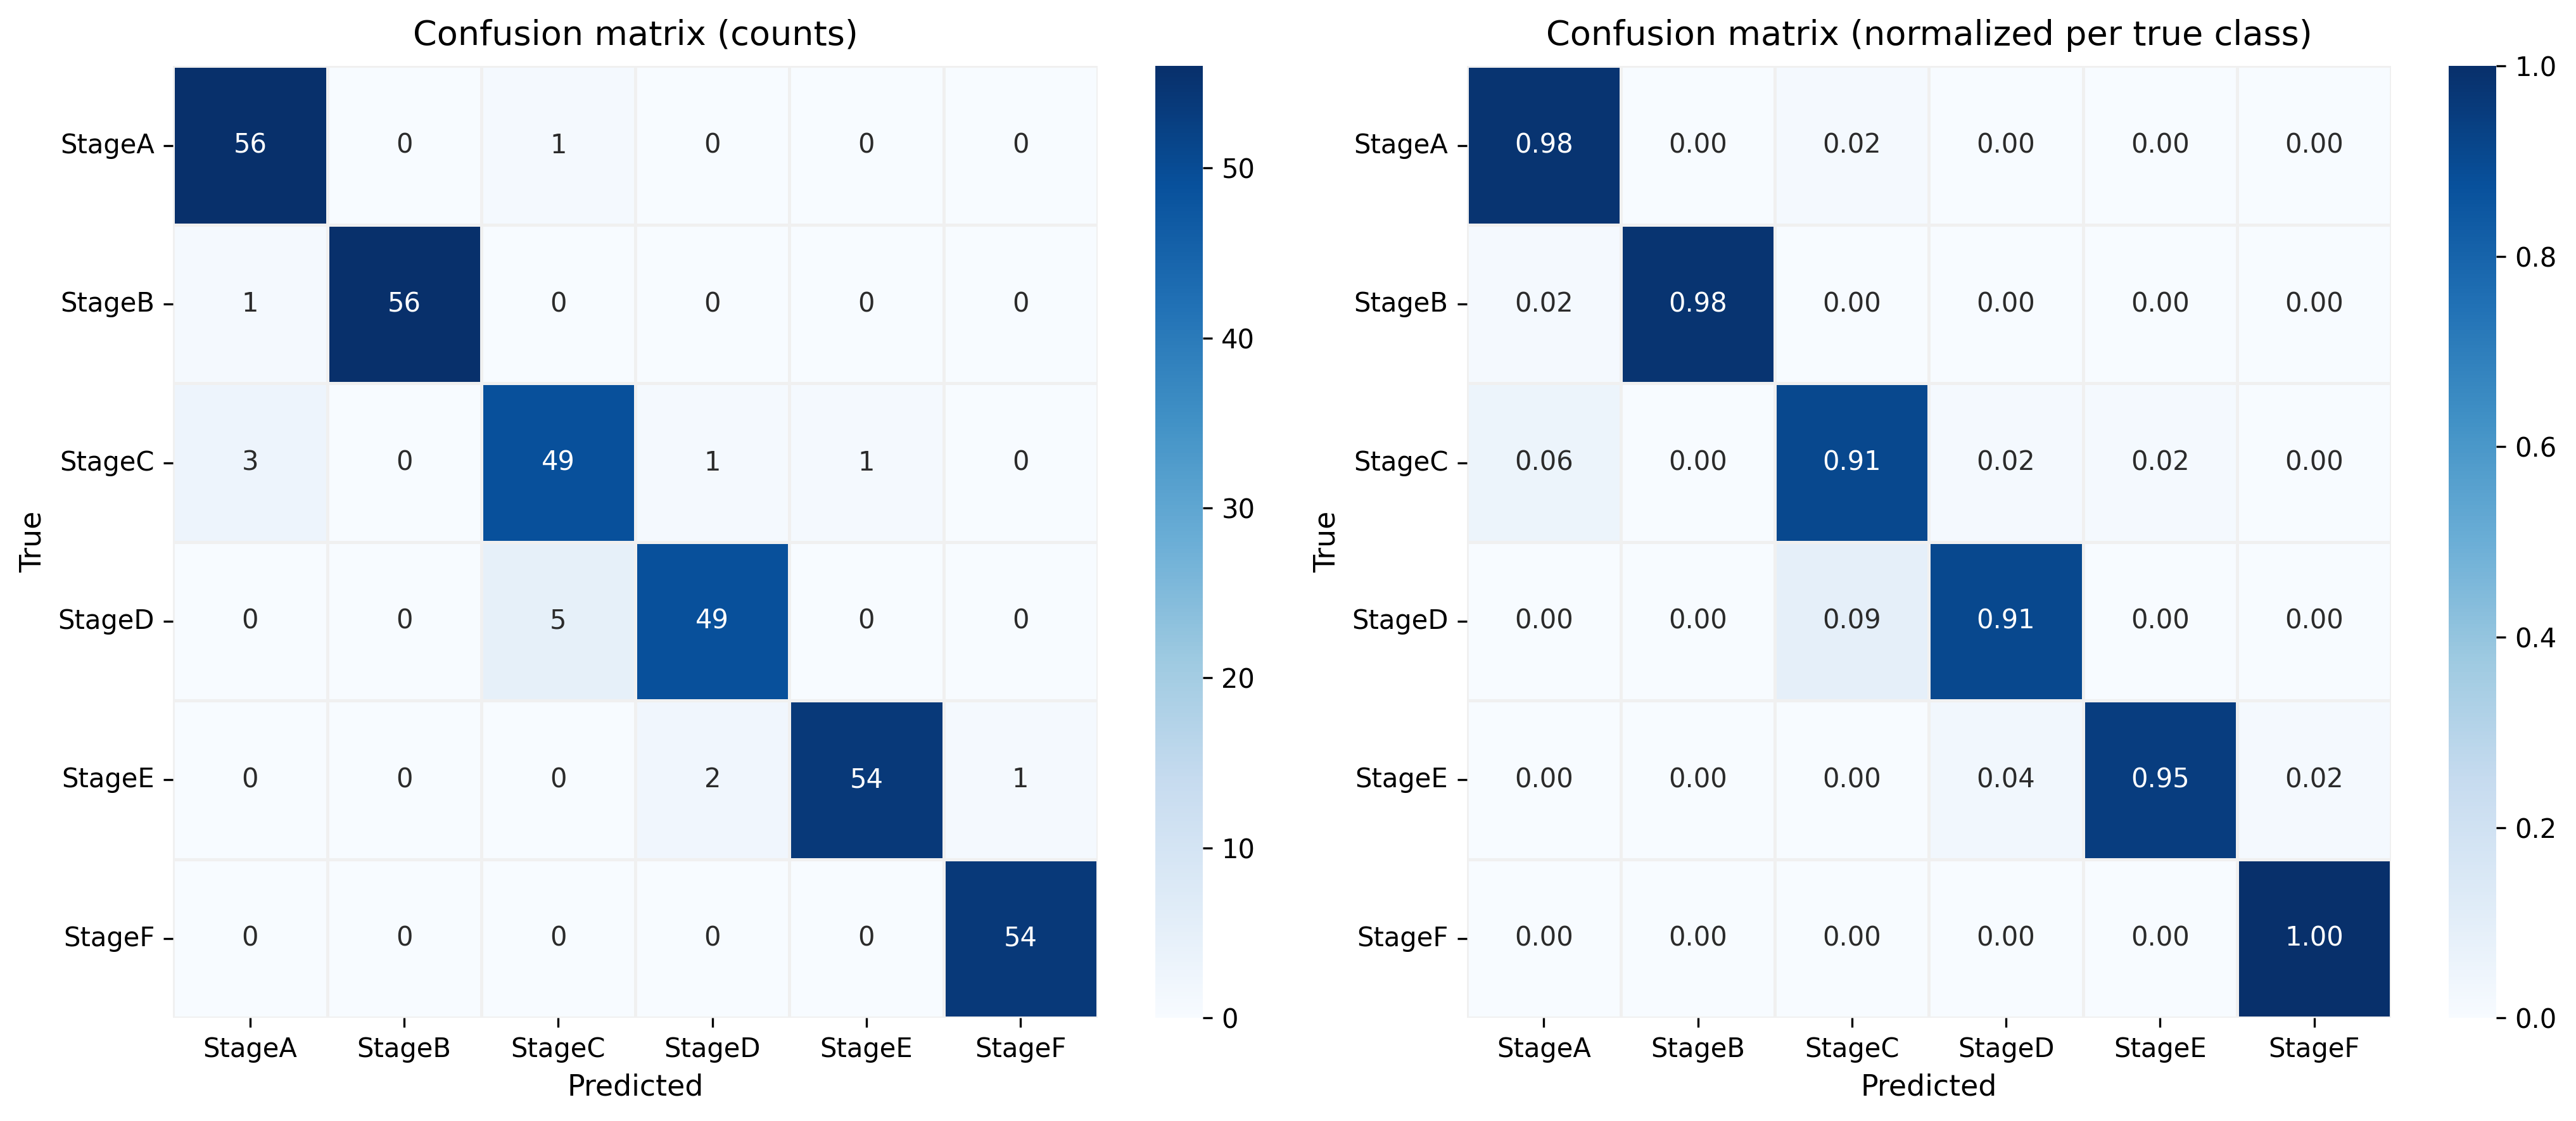

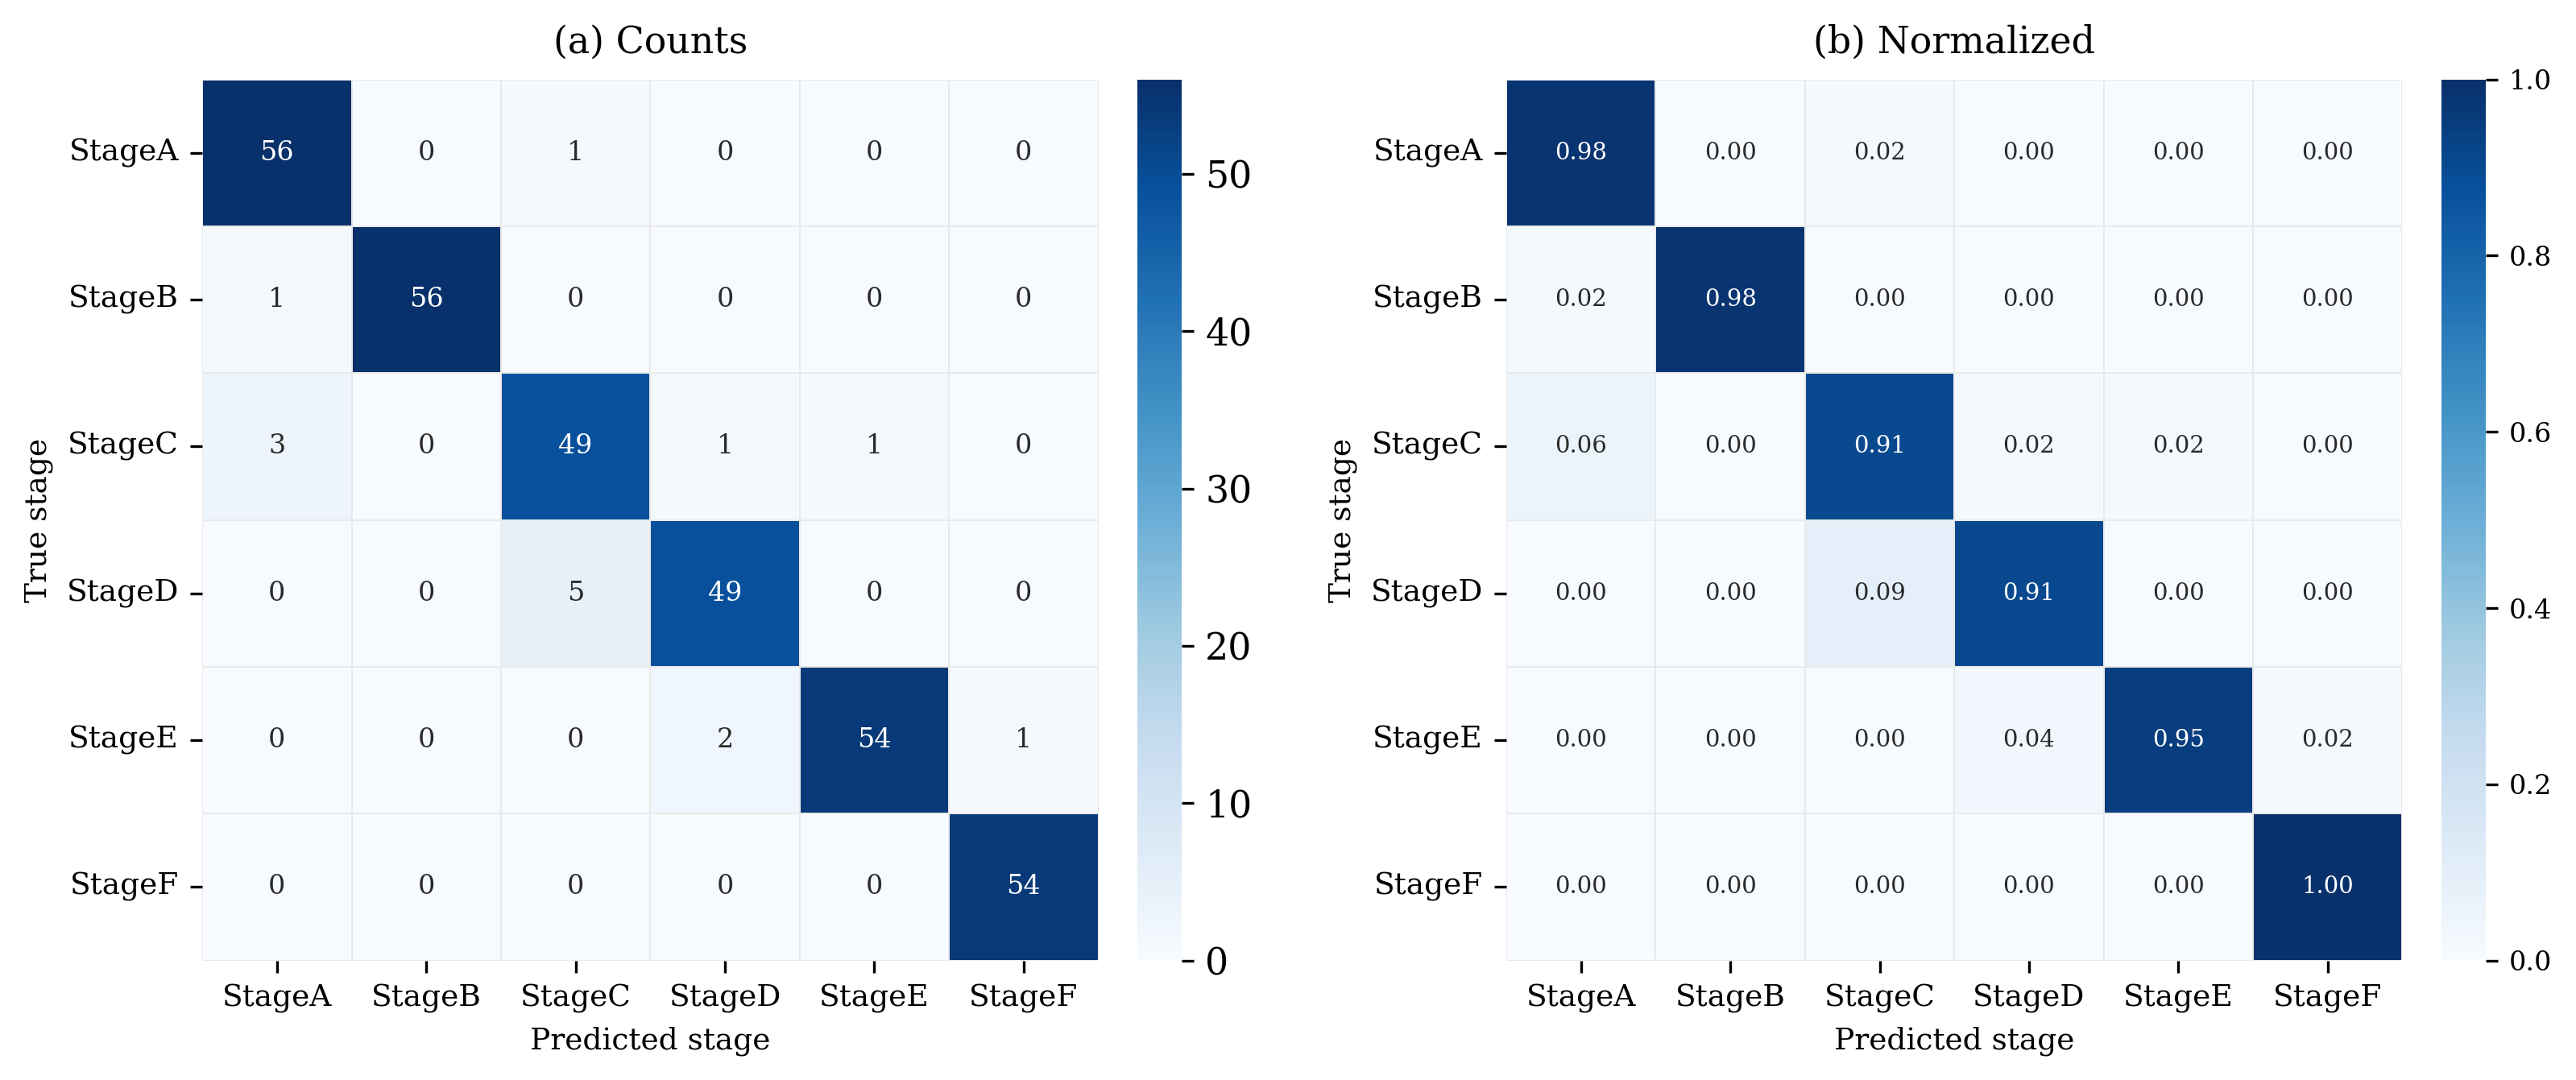

Saved: results\confusion_matrix_test_standard.png
Saved: results\confusion_matrix_test_manuscript.png


In [9]:
# ============================================================
# Test-set evaluation
# ============================================================

y_test_pred = best_model.predict(X_test)

test_summary, report_test_df = evaluate_predictions(
    y_test,
    y_test_pred,
    CLASS_NAMES,
    dataset_name="test",
    output_dir=OUTPUT_DIR
)

test_results_df = pd.DataFrame({
    "filepath": fp_test,
    "true_label": y_test,
    "predicted_label": y_test_pred,
    "correct": y_test == y_test_pred
})

test_results_df.to_csv(
    OUTPUT_DIR / "test_predictions.csv",
    index=False
)

cm_test, cm_test_norm = plot_confusion_matrix(
    y_test,
    y_test_pred,
    CLASS_NAMES,
    dataset_name="test",
    output_dir=OUTPUT_DIR
)

In [10]:
# ============================================================
# Save final model artifact
# ============================================================

model_artifact = {
    "model": best_model,
    "class_names": CLASS_NAMES,
    "img_size": IMG_SIZE,
    "radii": RADII,
    "lbp_method": LBP_METHOD,
    "glcm_distances": GLCM_DISTANCES,
    "glcm_angles": GLCM_ANGLES,
    "glcm_levels": GLCM_LEVELS,
    "glcm_properties": GLCM_PROPERTIES,
    "use_clahe": USE_CLAHE,
    "clahe_clip": CLAHE_CLIP,
    "clahe_grid": CLAHE_GRID,
    "crop_scalebar": CROP_SCALEBAR,
    "crop_ratio": CROP_RATIO,
    "final_pca_components": FINAL_PCA_COMPONENTS,
    "random_state": RANDOM_STATE,
    "feature_count": TOTAL_FEATURE_COUNT,
    "lbp_feature_count": LBP_FEATURE_COUNT,
    "glcm_feature_count": GLCM_FEATURE_COUNT,
    "best_params": grid_final.best_params_,
    "best_cv_accuracy": grid_final.best_score_,
    "test_summary": test_summary
}

joblib.dump(
    model_artifact,
    MODEL_PATH
)

print(f"\n[OK] Final model artifact saved to: {MODEL_PATH}")

# Save configuration as JSON for GitHub transparency
config_json = model_artifact.copy()
config_json["model"] = "sklearn Pipeline object; saved in joblib artifact"

for key, value in list(config_json.items()):
    if isinstance(value, (np.integer, np.floating)):
        config_json[key] = value.item()

with open(
    OUTPUT_DIR / "final_model_configuration.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        config_json,
        f,
        indent=4,
        default=str
    )


[OK] Final model artifact saved to: models\model_lbp_glcm_pca50_svm_final.pkl



[OK] Loading cached features from: features\features_lbp_glcm_validation.npz

VALIDATION SET EVALUATION
Accuracy          : 0.968750
Weighted precision: 0.973214
Weighted recall   : 0.968750
Weighted F1-score : 0.968216
Macro precision   : 0.976190
Macro recall      : 0.966667
Macro F1-score    : 0.968661

Classification report:
              precision    recall  f1-score   support

      StageA     1.0000    1.0000    1.0000         5
      StageB     1.0000    1.0000    1.0000         5
      StageC     0.8571    1.0000    0.9231         6
      StageD     1.0000    0.8000    0.8889         5
      StageE     1.0000    1.0000    1.0000         5
      StageF     1.0000    1.0000    1.0000         6

    accuracy                         0.9688        32
   macro avg     0.9762    0.9667    0.9687        32
weighted avg     0.9732    0.9688    0.9682        32



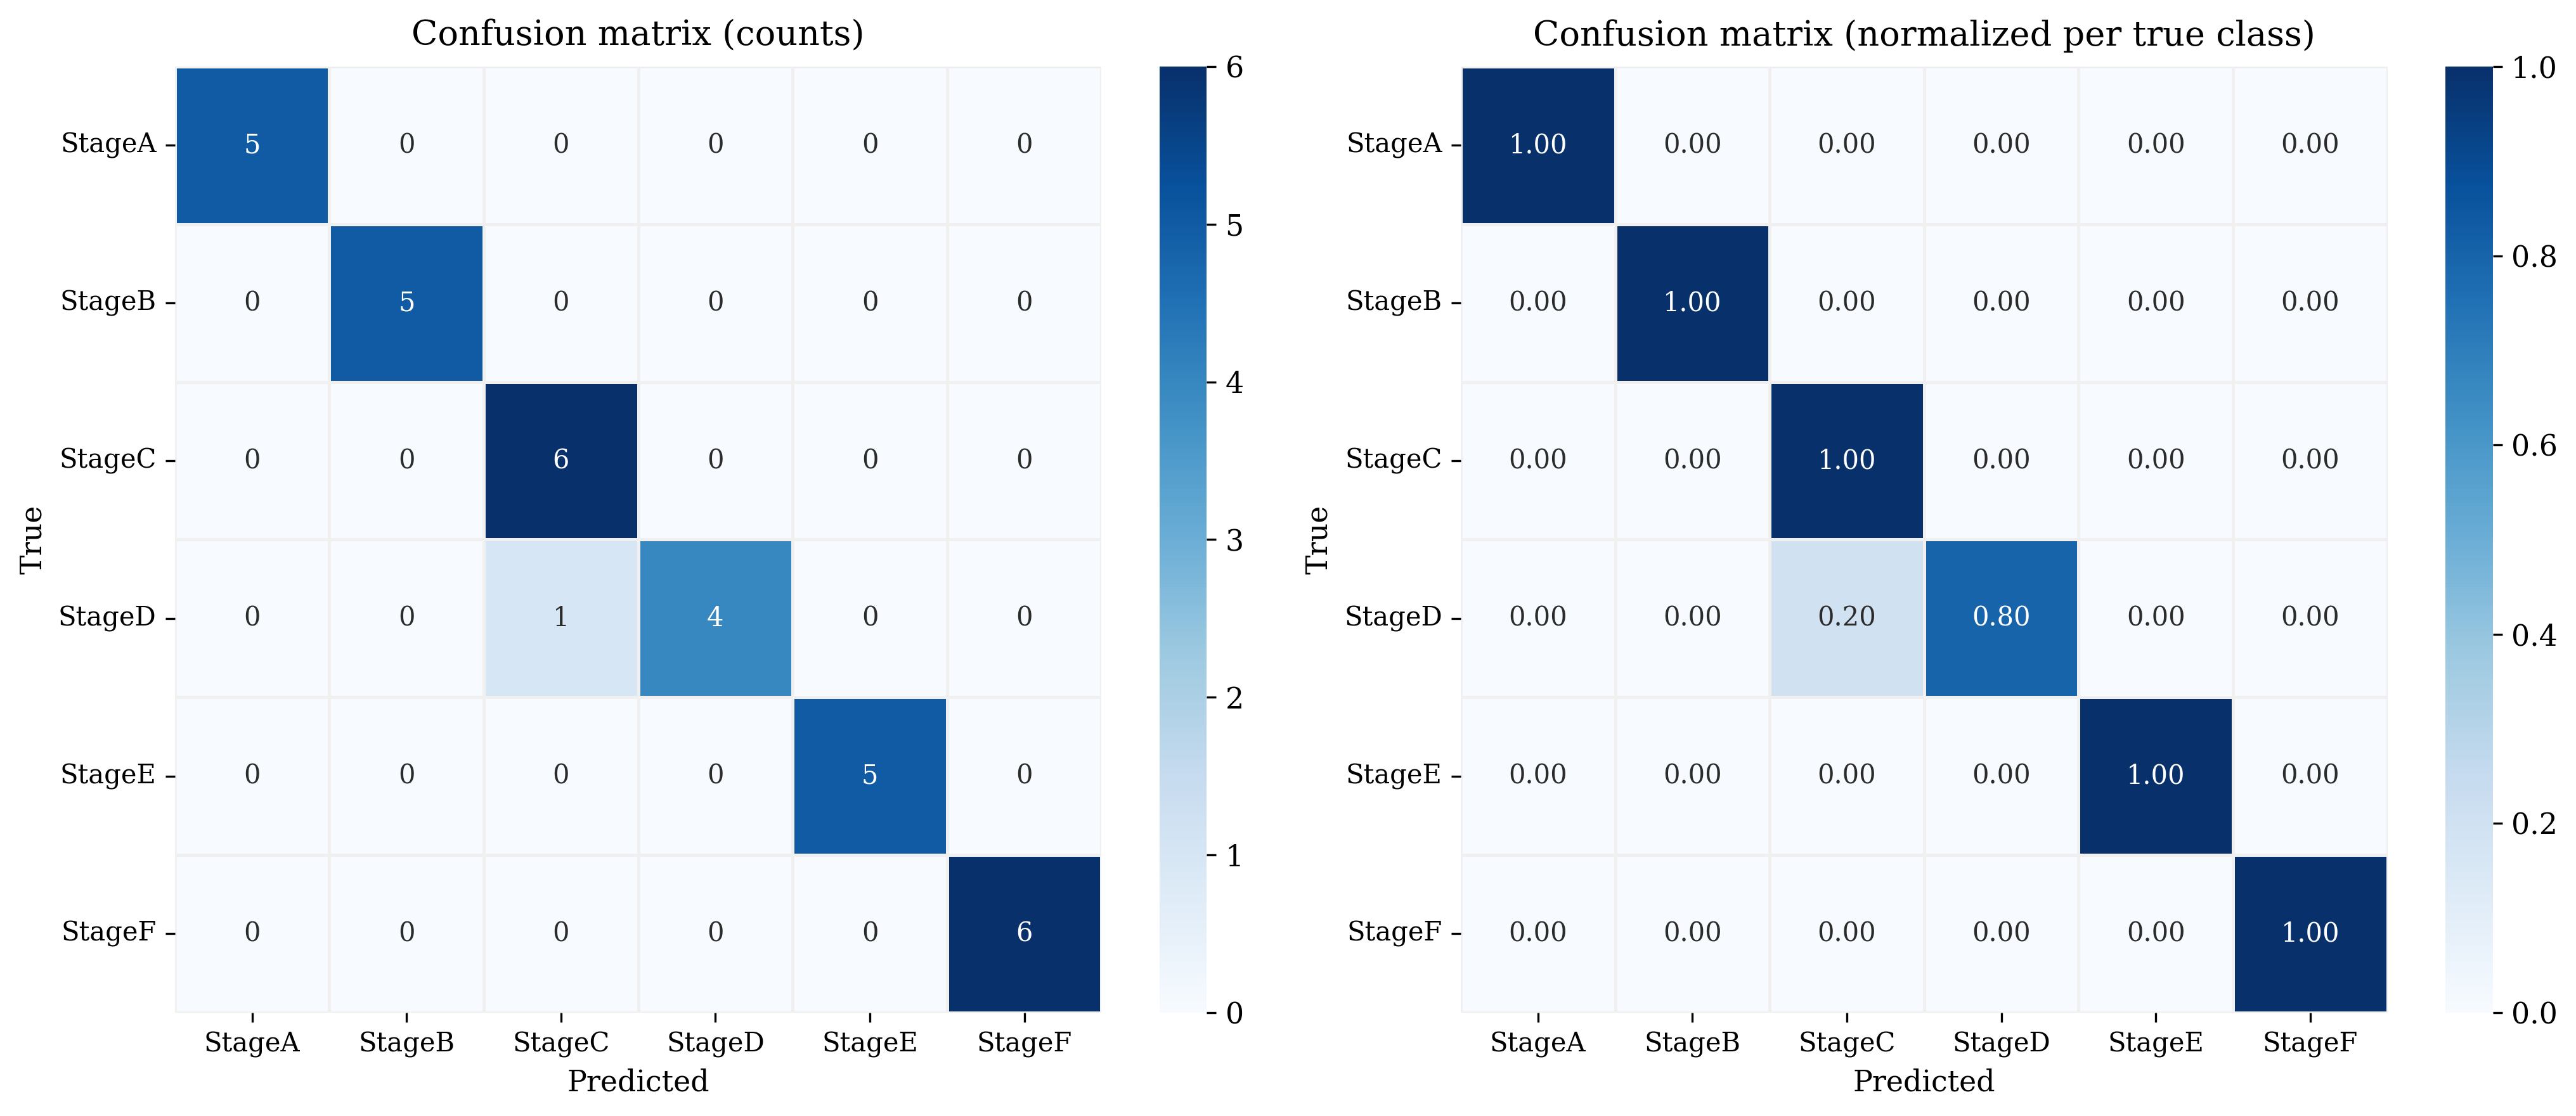

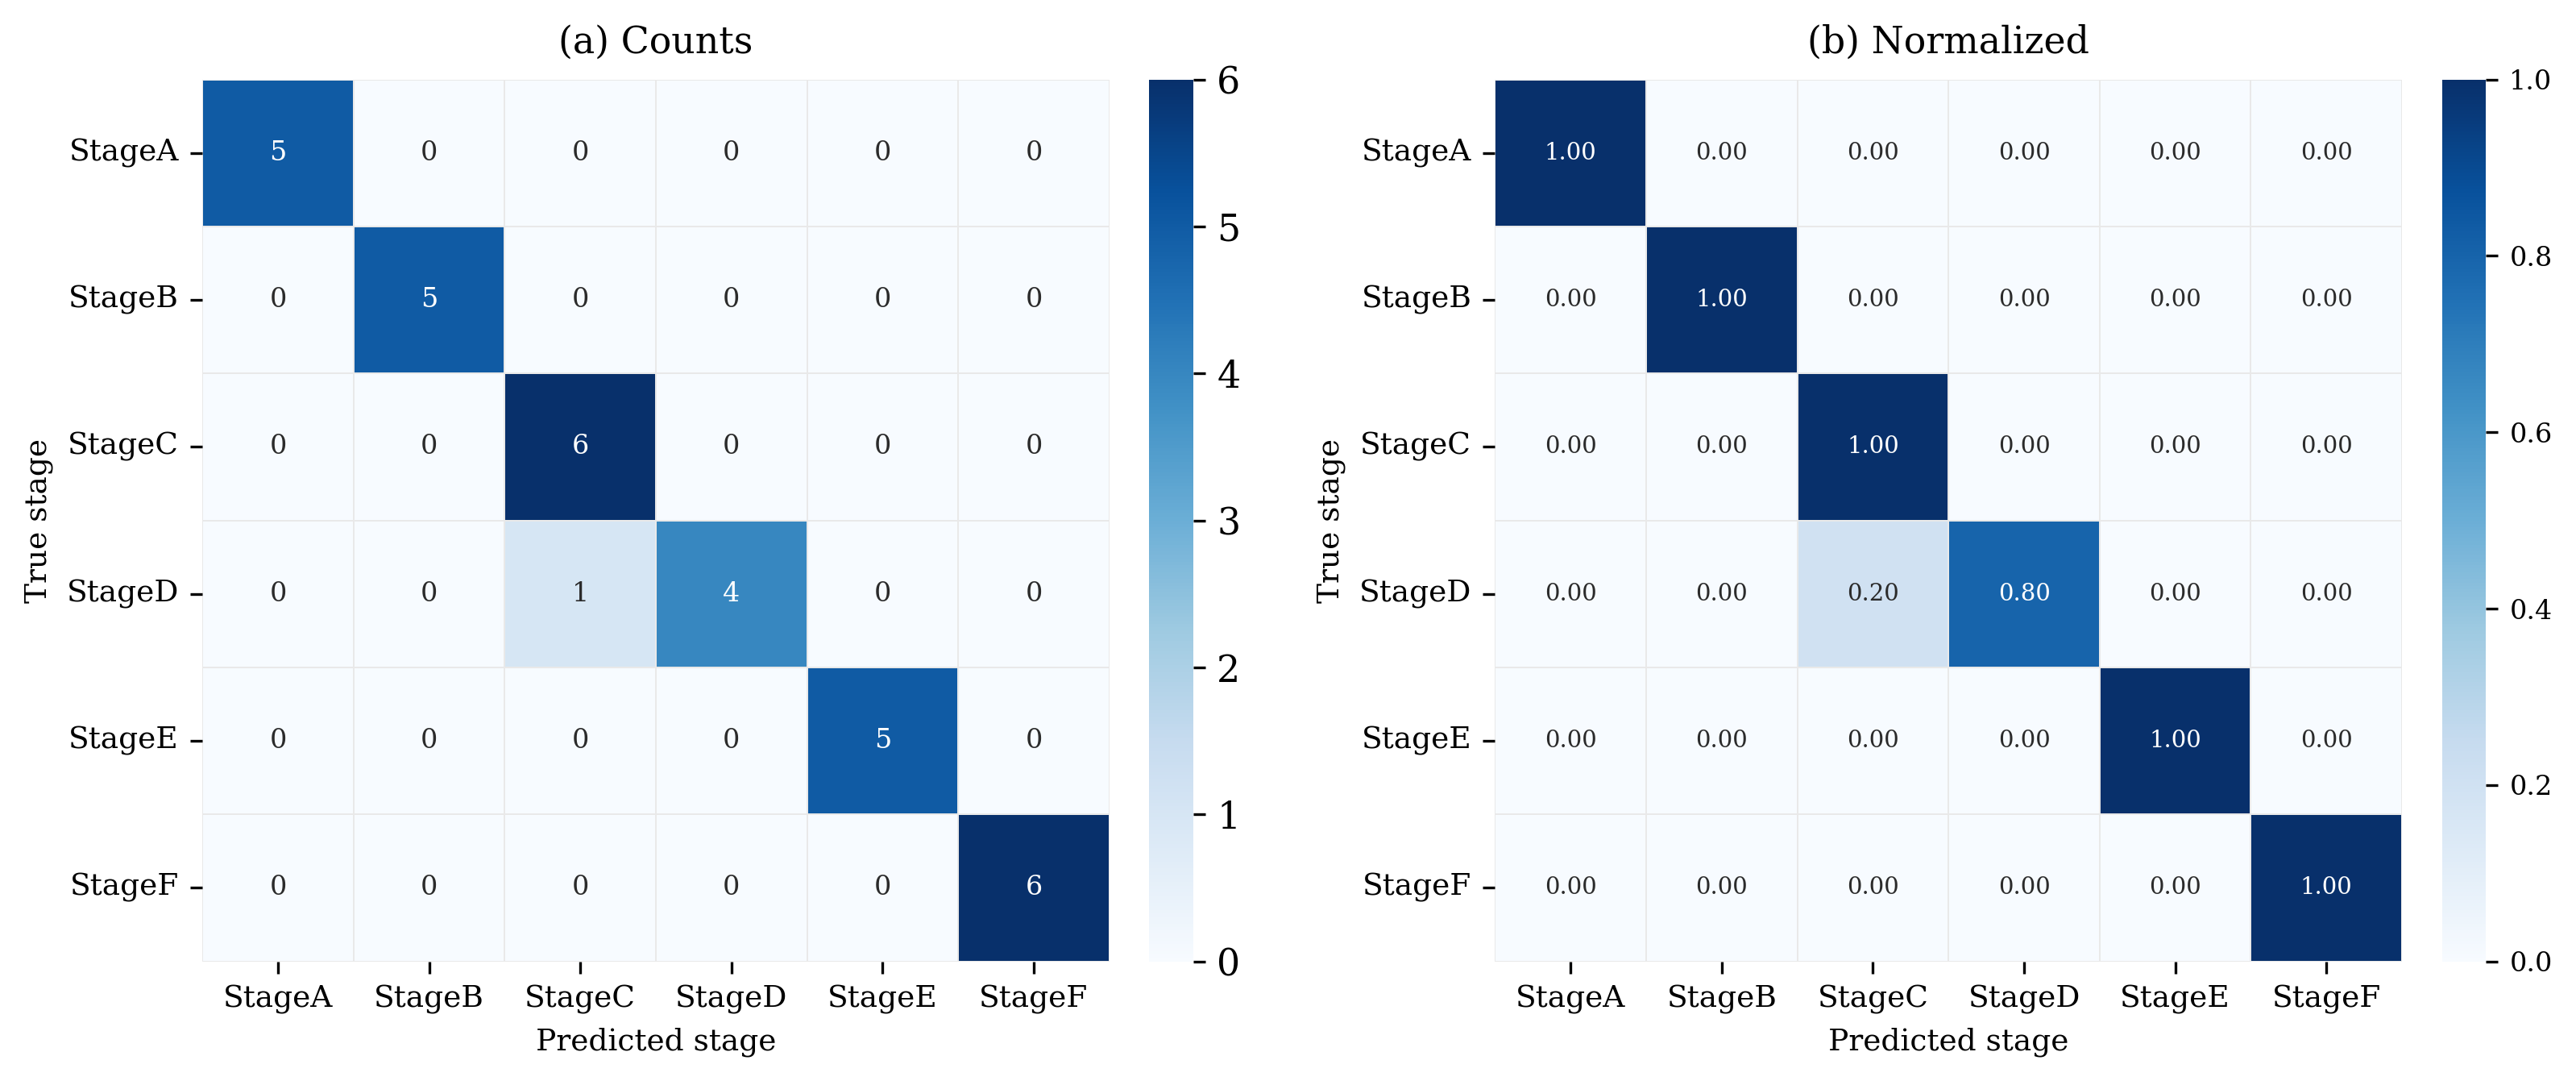

Saved: results\confusion_matrix_validation_standard.png
Saved: results\confusion_matrix_validation_manuscript.png


In [11]:
# ============================================================
# Independent validation
# ============================================================

VAL_FEATURE_CACHE = FEATURE_DIR / "features_lbp_glcm_validation.npz"

if VALIDATION_DIR.exists():

    X_val, y_val, fp_val = build_feature_matrix(
        VALIDATION_DIR,
        CLASS_NAMES,
        cache_path=VAL_FEATURE_CACHE,
        use_cache=True
    )

    y_val_pred = best_model.predict(X_val)

    val_summary, report_val_df = evaluate_predictions(
        y_val,
        y_val_pred,
        CLASS_NAMES,
        dataset_name="validation",
        output_dir=OUTPUT_DIR
    )

    val_results_df = pd.DataFrame({
        "filepath": fp_val,
        "true_label": y_val,
        "predicted_label": y_val_pred,
        "correct": y_val == y_val_pred
    })

    val_results_df.to_csv(
        OUTPUT_DIR / "validation_predictions.csv",
        index=False
    )

    cm_val, cm_val_norm = plot_confusion_matrix(
        y_val,
        y_val_pred,
        CLASS_NAMES,
        dataset_name="validation",
        output_dir=OUTPUT_DIR
    )

else:
    val_summary = None
    print(f"\n[INFO] Validation directory not found. Skipping independent validation: {VALIDATION_DIR}")


Metrics summary:
            Dataset   Accuracy  Precision     Recall   F1-score
0  Cross-validation  96.396046        NaN        NaN        NaN
1           Testing  95.495495  95.548206  95.495495  95.496558
2        Validation  96.875000  97.321429  96.875000  96.821581


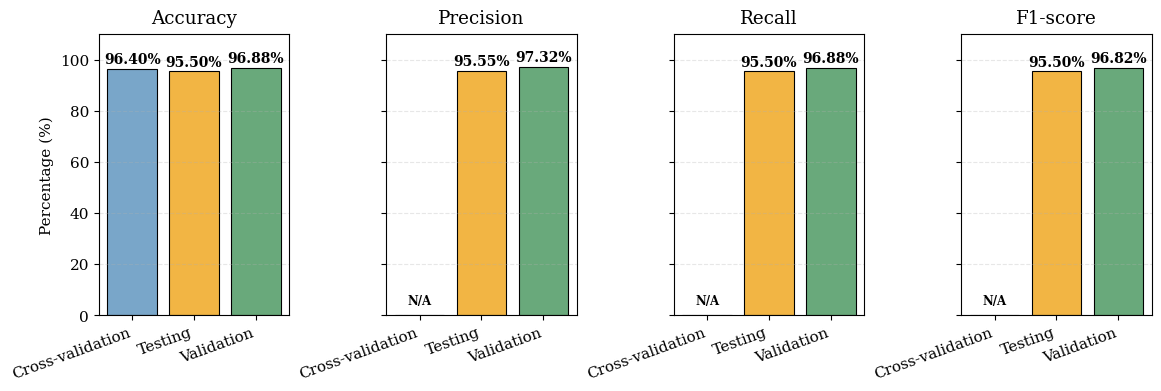

Figure saved as: results\metrics_comparison.png
Figure saved as: results\metrics_comparison.tif


In [12]:
# ===============================
# Dynamic metrics summary figure
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Common journal style
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11
})

# ============================================================
# Build metrics dynamically from actual model outputs
# ============================================================

# Cross-validation accuracy
if "fold_scores" in globals():
    cv_accuracy = np.mean(fold_scores)
elif "grid_final" in globals():
    cv_accuracy = grid_final.best_score_
else:
    cv_accuracy = np.nan

metrics_rows = []

metrics_rows.append({
    "Dataset": "Cross-validation",
    "Accuracy": cv_accuracy * 100 if not np.isnan(cv_accuracy) else np.nan,
    "Precision": np.nan,
    "Recall": np.nan,
    "F1-score": np.nan
})

metrics_rows.append({
    "Dataset": "Testing",
    "Accuracy": test_summary["accuracy"] * 100,
    "Precision": test_summary["weighted_precision"] * 100,
    "Recall": test_summary["weighted_recall"] * 100,
    "F1-score": test_summary["weighted_f1"] * 100
})

if "val_summary" in globals() and val_summary is not None:
    metrics_rows.append({
        "Dataset": "Validation",
        "Accuracy": val_summary["accuracy"] * 100,
        "Precision": val_summary["weighted_precision"] * 100,
        "Recall": val_summary["weighted_recall"] * 100,
        "F1-score": val_summary["weighted_f1"] * 100
    })

metrics_summary = pd.DataFrame(metrics_rows)

metrics_summary.to_csv(
    OUTPUT_DIR / "metrics_summary.csv",
    index=False
)

print("\nMetrics summary:")
print(metrics_summary)

# =========================
# Old figure style
# =========================
plot_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

colors = [
    "#79A6C9",  # Cross-validation
    "#F2B544",  # Testing
    "#69A97B"   # Validation
]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(11.5, 3.8),
    sharey=True,
    constrained_layout=True
)

for ax, metric in zip(axes, plot_metrics):
    values = metrics_summary[metric].values
    x_labels = metrics_summary["Dataset"].values
    x = np.arange(len(x_labels))

    for i, value in enumerate(values):

        if np.isnan(value):
            ax.bar(
                x[i],
                0,
                color="white",
                edgecolor="black",
                linewidth=0.8,
                hatch="//"
            )

            ax.text(
                x[i],
                3.0,
                "N/A",
                ha="center",
                va="bottom",
                fontsize=8.5,
                fontweight="bold"
            )

        else:
            ax.bar(
                x[i],
                value,
                color=colors[i],
                edgecolor="black",
                linewidth=0.8
            )

            ax.text(
                x[i],
                value + 1.0,
                f"{value:.2f}%",
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold"
            )

    ax.set_title(metric, pad=8)
    ax.set_xticks(x)

    ax.set_xticklabels(
        x_labels,
        rotation=20,
        ha="right"
    )

    ax.set_ylim(0, 110)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

axes[0].set_ylabel("Percentage (%)")

output_png = OUTPUT_DIR / "metrics_comparison.png"
output_tif = OUTPUT_DIR / "metrics_comparison.tif"

plt.savefig(
    output_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    output_tif,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved as: {output_png}")
print(f"Figure saved as: {output_tif}")


Selected cumulative explained variance:
n =  20 | cumulative explained variance = 99.193077%
n =  50 | cumulative explained variance = 99.874458%
n =  80 | cumulative explained variance = 99.998489%
n = 100 | cumulative explained variance = 99.999939%
n = 120 | cumulative explained variance = 100.000000%
n = 126 | cumulative explained variance = 100.000000%

Variance thresholds:
95.00% variance reached at n = 5
99.00% variance reached at n = 18
99.90% variance reached at n = 53
99.99% variance reached at n = 68


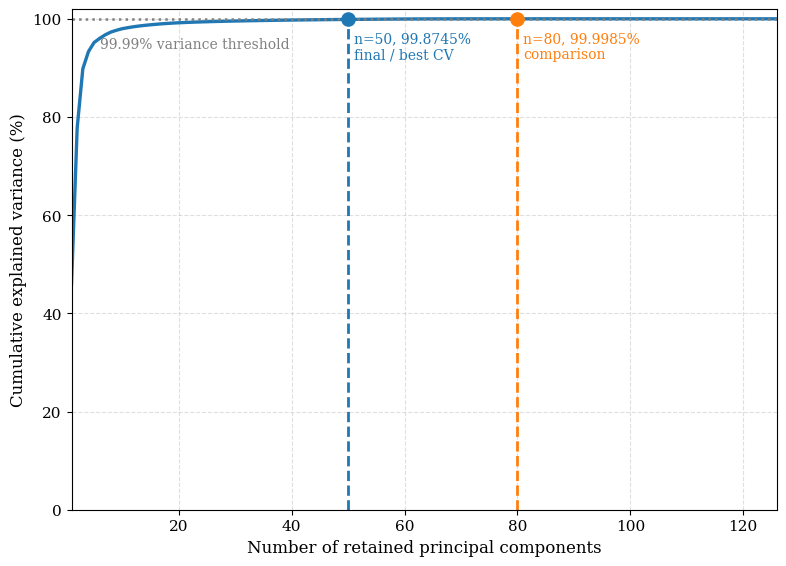

Figure saved to: results\cumulative_explained_variance_pca.png
Figure saved to: results\cumulative_explained_variance_pca.tif


In [13]:
# ============================================================
# PCA explained variance analysis
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Standardize training data only
# ============================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# ============================================================
# Full PCA on standardized training features
# ============================================================

pca_full = PCA(
    n_components=None,
    svd_solver="full"
)

pca_full.fit(X_train_scaled)

cumvar = np.cumsum(
    pca_full.explained_variance_ratio_
) * 100

n_comp = np.arange(1, len(cumvar) + 1)

# ============================================================
# Save PCA variance table
# ============================================================

pca_variance_df = pd.DataFrame({
    "n_components": n_comp,
    "cumulative_explained_variance_percent": cumvar
})

pca_variance_df.to_csv(
    OUTPUT_DIR / "pca_cumulative_explained_variance.csv",
    index=False
)

# ============================================================
# Print exact values for manuscript reporting
# ============================================================

print("\nSelected cumulative explained variance:")

for n_sel in [20, 50, 80, 100, 120, 126]:
    if n_sel <= len(cumvar):
        print(
            f"n = {n_sel:3d} | cumulative explained variance = {cumvar[n_sel - 1]:.6f}%"
        )

print("\nVariance thresholds:")

for threshold in [95, 99, 99.9, 99.99]:
    n_threshold = np.argmax(cumvar >= threshold) + 1
    print(
        f"{threshold:.2f}% variance reached at n = {n_threshold}"
    )

# ============================================================
# Old figure style
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 5.8)
)

ax.plot(
    n_comp,
    cumvar,
    linewidth=2.4
)

# Horizontal threshold line
ax.axhline(
    99.99,
    linestyle=":",
    linewidth=1.8,
    color="gray"
)

ax.text(
    6,
    99.99 - 6,
    "99.99% variance threshold",
    fontsize=10,
    color="gray"
)

# ============================================================
# Mark n = 50 and n = 80, following previous figure format
# ============================================================

markers = [
    (50, "tab:blue", "final / best CV"),
    (80, "tab:orange", "comparison")
]

for n_sel, color, label in markers:
    if n_sel <= len(cumvar):
        ax.axvline(
            n_sel,
            linestyle="--",
            linewidth=2,
            color=color
        )

        ax.scatter(
            [n_sel],
            [cumvar[n_sel - 1]],
            s=90,
            color=color,
            zorder=3
        )

        ax.text(
            n_sel + 1,
            cumvar[n_sel - 1] - 8,
            f"n={n_sel}, {cumvar[n_sel - 1]:.4f}%\n{label}",
            color=color,
            fontsize=10
        )

ax.set_xlabel(
    "Number of retained principal components",
    fontsize=12
)

ax.set_ylabel(
    "Cumulative explained variance (%)",
    fontsize=12
)

ax.set_ylim(0, 102)
ax.set_xlim(1, len(cumvar))

ax.grid(
    True,
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

output_png = OUTPUT_DIR / "cumulative_explained_variance_pca.png"
output_tif = OUTPUT_DIR / "cumulative_explained_variance_pca.tif"

plt.savefig(
    output_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    output_tif,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {output_png}")
print(f"Figure saved to: {output_tif}")


Best heatmap cell:
C       : 50
gamma   : scale
CV mean : 0.963960
CV std  : 0.003859


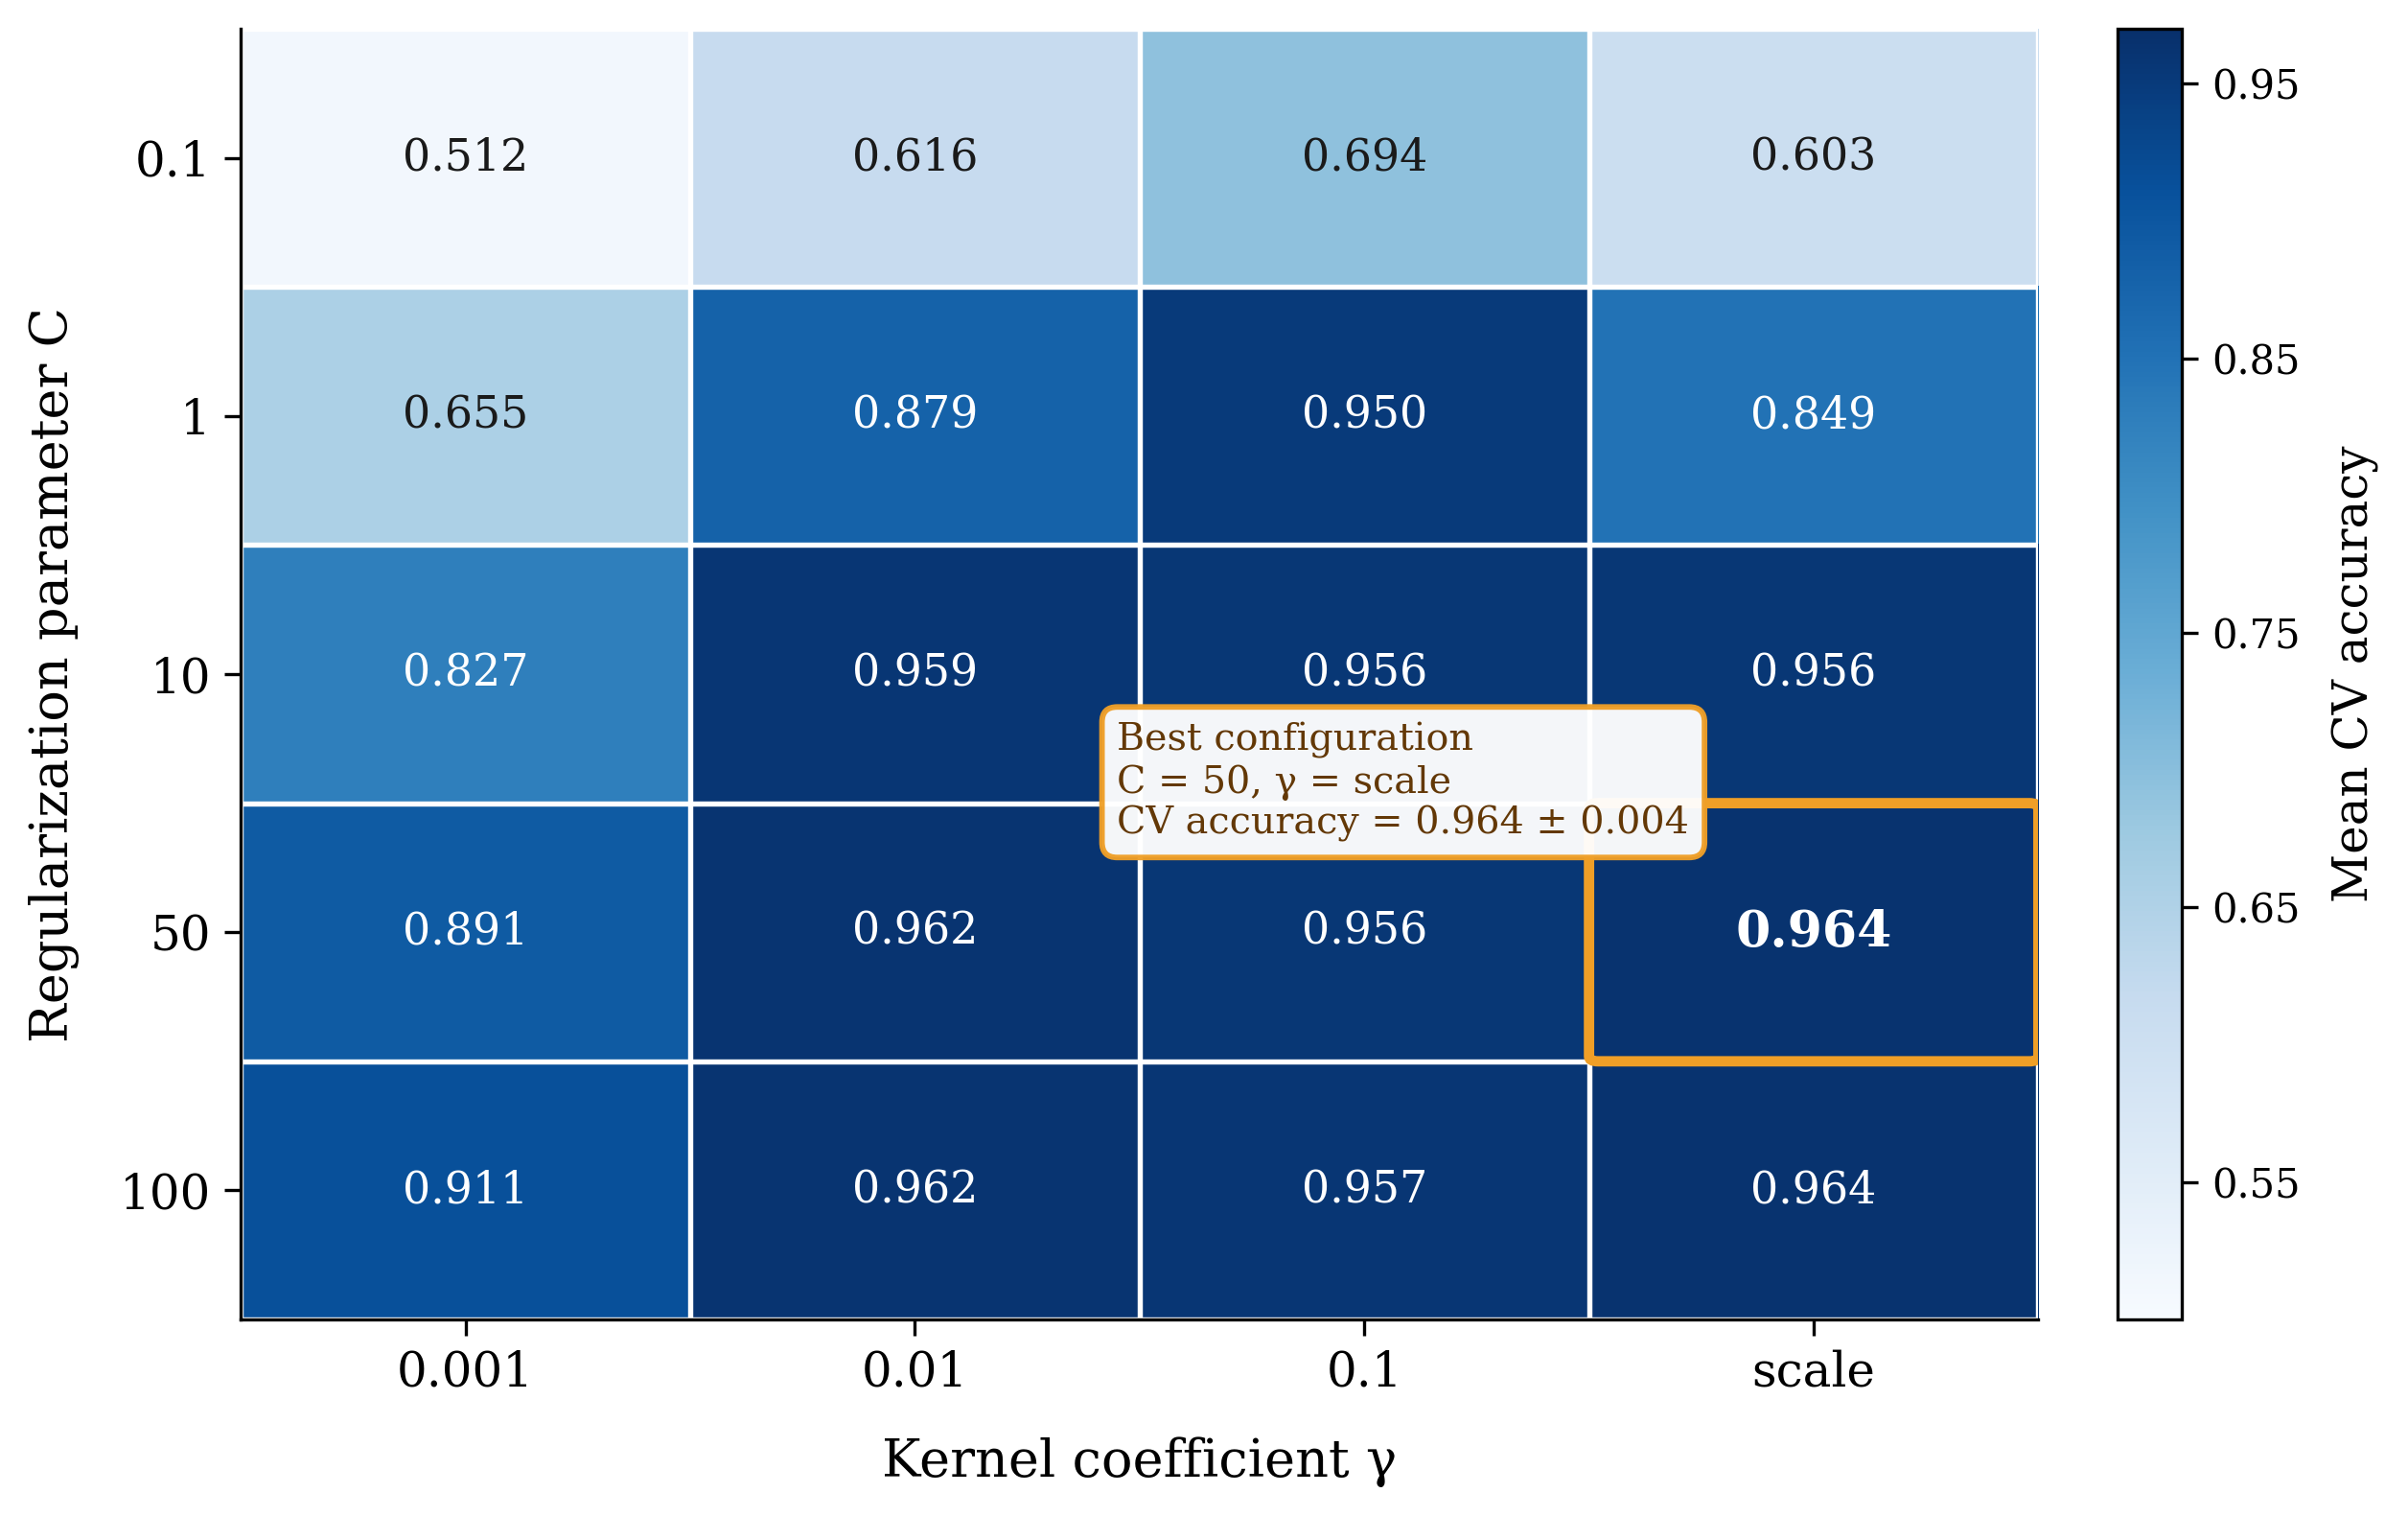

Saved: results\GridSearch_Heatmap_PCA_50.png
Saved: results\GridSearch_Heatmap_PCA_50.tif


In [14]:
# ============================================================
# Hyperparameter heatmap 
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

from matplotlib.colors import Normalize

# ============================================================
# Use GridSearchCV results from the final trained model
# ============================================================

if "cv_results_final" in globals():
    cv_results_df = cv_results_final.copy()
elif "grid_final" in globals():
    cv_results_df = pd.DataFrame(grid_final.cv_results_)
else:
    raise NameError(
        "cv_results_final or grid_final is not defined. "
        "Please run the final GridSearchCV training cell first."
    )

# ============================================================
# Define axis order
# ============================================================

C_order = [
    0.1,
    1,
    10,
    50,
    100
]

gamma_order = [
    0.001,
    0.01,
    0.1,
    "scale"
]

cv_results_df["param_svc__C"] = cv_results_df["param_svc__C"].astype(float)


def convert_gamma(x):
    if str(x) == "scale":
        return "scale"
    return float(x)


cv_results_df["param_svc__gamma"] = cv_results_df["param_svc__gamma"].apply(
    convert_gamma
)

# ============================================================
# Build matrices for heatmap
# ============================================================

mean_score_df = cv_results_df.pivot(
    index="param_svc__C",
    columns="param_svc__gamma",
    values="mean_test_score"
).reindex(
    index=C_order,
    columns=gamma_order
)

std_score_df = cv_results_df.pivot(
    index="param_svc__C",
    columns="param_svc__gamma",
    values="std_test_score"
).reindex(
    index=C_order,
    columns=gamma_order
)

mean_score_df.to_csv(
    OUTPUT_DIR / f"cv_heatmap_mean_score_pca{FINAL_PCA_COMPONENTS}.csv"
)

std_score_df.to_csv(
    OUTPUT_DIR / f"cv_heatmap_std_score_pca{FINAL_PCA_COMPONENTS}.csv"
)

cv_data = mean_score_df.to_numpy()
std_data = std_score_df.to_numpy()

best_idx = np.nanargmax(cv_data)
best_row, best_col = np.unravel_index(
    best_idx,
    cv_data.shape
)

best_C = C_order[best_row]
best_gamma = gamma_order[best_col]
best_mean = cv_data[best_row, best_col]
best_std = std_data[best_row, best_col]

print("\nBest heatmap cell:")
print(f"C       : {best_C}")
print(f"gamma   : {best_gamma}")
print(f"CV mean : {best_mean:.6f}")
print(f"CV std  : {best_std:.6f}")

# ============================================================
# Journal-style figure settings from previous notebook
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

DPI = 300
W_IN = 8.5
H_IN = 5.4

fig, ax = plt.subplots(
    figsize=(W_IN, H_IN),
    dpi=DPI
)

fig.patch.set_facecolor("white")

# ============================================================
# Old heatmap style
# ============================================================

vmin, vmax = 0.50, 0.97

norm = Normalize(
    vmin=vmin,
    vmax=vmax
)

cmap = plt.get_cmap("Blues")

im = ax.imshow(
    cv_data,
    cmap=cmap,
    norm=norm,
    aspect="auto"
)

n_rows, n_cols = cv_data.shape

for i in range(n_rows):
    for j in range(n_cols):
        val = cv_data[i, j]

        if np.isnan(val):
            text_str = "NA"
            tcol = "black"
            weight = "normal"
            size = 11

        else:
            rgba = cmap(norm(val))
            r, g, b, _ = rgba

            lum = (
                0.299 * r +
                0.587 * g +
                0.114 * b
            )

            tcol = "#1a1a1a" if lum > 0.50 else "white"

            is_best = (
                i == best_row and
                j == best_col
            )

            weight = "bold" if is_best else "normal"
            size = 12.5 if is_best else 11
            text_str = f"{val:.3f}"

        ax.text(
            j,
            i,
            text_str,
            ha="center",
            va="center",
            color=tcol,
            fontsize=size,
            fontweight=weight
        )

# ============================================================
# Highlight best cell — previous notebook style
# ============================================================

rect = mpatches.FancyBboxPatch(
    (best_col - 0.48, best_row - 0.48),
    0.96,
    0.96,
    boxstyle="round,pad=0.02",
    linewidth=2.6,
    edgecolor="#EF9F27",
    facecolor="none",
    zorder=5
)

ax.add_patch(rect)

xytext_x = best_col - 1.55
xytext_y = best_row - 0.38

ax.annotate(
    f"Best configuration\nC = {best_C}, γ = {best_gamma}\nCV accuracy = {best_mean:.3f} ± {best_std:.3f}",
    xy=(best_col, best_row),
    xytext=(xytext_x, xytext_y),
    fontsize=9.5,
    color="#633806",
    bbox=dict(
        boxstyle="round,pad=0.40",
        fc="white",
        ec="#EF9F27",
        lw=1.4,
        alpha=0.96
    ),
    zorder=7
)

# ============================================================
# Axes, labels, and grid — previous notebook style
# ============================================================

gamma_labels = [
    "0.001",
    "0.01",
    "0.1",
    "scale"
]

C_labels = [
    "0.1",
    "1",
    "10",
    "50",
    "100"
]

ax.set_xticks(
    np.arange(n_cols)
)

ax.set_yticks(
    np.arange(n_rows)
)

ax.set_xticklabels(
    gamma_labels,
    fontsize=12
)

ax.set_yticklabels(
    C_labels,
    fontsize=12
)

ax.set_xlabel(
    "Kernel coefficient γ",
    fontsize=13,
    labelpad=10
)

ax.set_ylabel(
    "Regularization parameter C",
    fontsize=13,
    labelpad=10
)

for i in np.arange(-0.5, n_rows, 1):
    ax.axhline(
        i,
        color="white",
        linewidth=1.3,
        zorder=2
    )

for j in np.arange(-0.5, n_cols, 1):
    ax.axvline(
        j,
        color="white",
        linewidth=1.3,
        zorder=2
    )

# ============================================================
# Colorbar — previous notebook style
# ============================================================

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

cbar.set_label(
    "Mean CV accuracy",
    fontsize=12,
    labelpad=8
)

cbar.ax.tick_params(
    labelsize=10
)

cbar.set_ticks([
    0.55,
    0.65,
    0.75,
    0.85,
    0.95
])

cbar.ax.yaxis.set_major_formatter(
    mticker.FormatStrFormatter("%.2f")
)

# ============================================================
# Save figure
# ============================================================

plt.tight_layout()

output_png = OUTPUT_DIR / f"GridSearch_Heatmap_PCA_{FINAL_PCA_COMPONENTS}.png"
output_tif = OUTPUT_DIR / f"GridSearch_Heatmap_PCA_{FINAL_PCA_COMPONENTS}.tif"

fig.savefig(
    output_png,
    dpi=DPI,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    output_tif,
    dpi=DPI,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Saved: {output_png}")
print(f"Saved: {output_tif}")

X_train shape: (1332, 126)
X_test shape : (333, 126)

Feature dimensions:
LBP only       : (1332, 54)
GLCM only      : (1332, 72)
LBP + GLCM     : (1332, 126)

GLCM only + SVM
Best parameters: {'svc__C': 50, 'svc__gamma': 0.1}
Mean CV accuracy : 0.924178
CV std           : 0.009273
Test accuracy    : 0.930931

Classification report:
              precision    recall  f1-score   support

      StageA       0.92      1.00      0.96        57
      StageB       0.98      0.91      0.95        57
      StageC       0.91      0.91      0.91        54
      StageD       0.92      0.85      0.88        54
      StageE       0.88      0.93      0.91        57
      StageF       0.98      0.98      0.98        54

    accuracy                           0.93       333
   macro avg       0.93      0.93      0.93       333
weighted avg       0.93      0.93      0.93       333


LBP only + SVM
Best parameters: {'svc__C': 10, 'svc__gamma': 0.1}
Mean CV accuracy : 0.941435
CV std           : 0.011818

,Model,Original features,SVM input dimension,PCA,Best C,Best gamma,Mean CV accuracy,CV std,Test accuracy,Weighted precision,Weighted recall,Weighted F1,Macro precision,Macro recall,Macro F1
0,GLCM only + SVM,72,72,No,50,0.1,0.9242,0.0093,0.9309,0.9320,0.9309,0.9306,0.9321,0.9305,0.9305
1,LBP only + SVM,54,54,No,10,0.1,0.9414,0.0118,0.9219,0.9245,0.9219,0.9221,0.9238,0.9220,0.9218
2,LBP + GLCM + SVM,126,126,No,100,scale,0.9640,0.0030,0.9550,0.9557,0.9550,0.9549,0.9554,0.9545,0.9545
3,LBP + GLCM + PCA(50)-SVM,126,50,"Yes, 50 PCs",50,scale,0.9640,0.0039,0.9550,0.9555,0.9550,0.9550,0.9550,0.9545,0.9545



Saved:
- ablation_study_summary_pca50.csv
- ablation_study_summary_pca50.xlsx


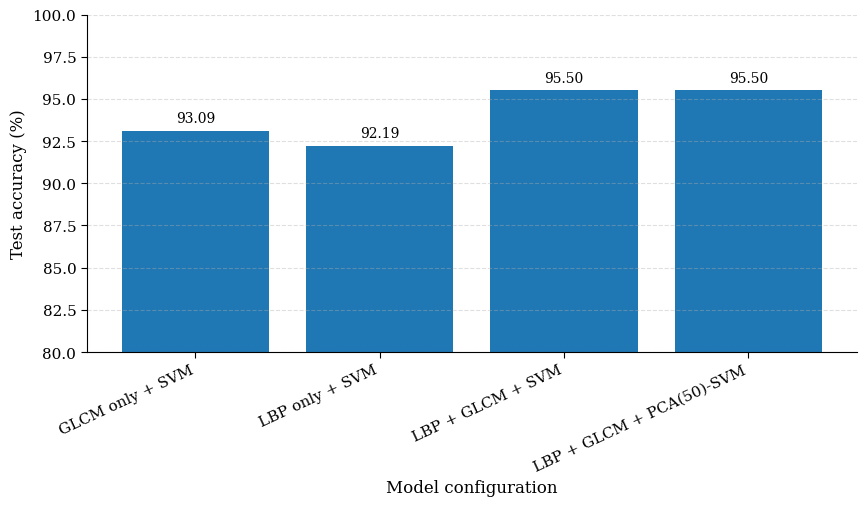

Figure saved to: ablation_test_accuracy_comparison_pca50.png


In [15]:
# ============================================================
# COMPLETE ABLATION STUDY PIPELINE
# GLCM only + SVM
# LBP only + SVM
# LBP + GLCM + SVM without PCA
# LBP + GLCM + PCA(50)-SVM
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

# ------------------------------------------------------------
# 1. Check and convert data
# ------------------------------------------------------------

required_vars = ["X_train", "X_test", "y_train", "y_test"]
for var in required_vars:
    if var not in globals():
        raise NameError(f"{var} is not defined. Please run the train-test split cell first.")

X_train_arr = X_train.to_numpy() if hasattr(X_train, "to_numpy") else np.asarray(X_train)
X_test_arr  = X_test.to_numpy() if hasattr(X_test, "to_numpy") else np.asarray(X_test)
y_train_arr = y_train.to_numpy() if hasattr(y_train, "to_numpy") else np.asarray(y_train)
y_test_arr  = y_test.to_numpy() if hasattr(y_test, "to_numpy") else np.asarray(y_test)

print("X_train shape:", X_train_arr.shape)
print("X_test shape :", X_test_arr.shape)

# ------------------------------------------------------------
# 2. Feature slicing
# ------------------------------------------------------------
# Assumption:
# X = [54 LBP features | 72 GLCM features]
# Total = 126 features

LBP_DIM = 54
GLCM_DIM = 72
TOTAL_DIM = LBP_DIM + GLCM_DIM

if X_train_arr.shape[1] != TOTAL_DIM:
    raise ValueError(
        f"Expected {TOTAL_DIM} features, but X_train has {X_train_arr.shape[1]} features. "
        "Please check whether your feature order or feature dimension is different."
    )

X_train_lbp = X_train_arr[:, :LBP_DIM]
X_test_lbp  = X_test_arr[:, :LBP_DIM]

X_train_glcm = X_train_arr[:, LBP_DIM:]
X_test_glcm  = X_test_arr[:, LBP_DIM:]

X_train_lbp_glcm = X_train_arr
X_test_lbp_glcm  = X_test_arr

print("\nFeature dimensions:")
print("LBP only       :", X_train_lbp.shape)
print("GLCM only      :", X_train_glcm.shape)
print("LBP + GLCM     :", X_train_lbp_glcm.shape)

# ------------------------------------------------------------
# 3. Common CV and hyperparameter grid
# ------------------------------------------------------------

RANDOM_STATE = 42
FINAL_N_COMPONENTS = 50

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

svm_param_grid = {
    "svc__C": [0.1, 1, 10, 50, 100],
    "svc__gamma": [0.001, 0.01, 0.1, "scale"]
}

# ------------------------------------------------------------
# 4. Evaluation function: SVM without PCA
# ------------------------------------------------------------

def evaluate_svm_baseline(model_name, Xtr, Xte, ytr, yte):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(
            kernel="rbf",
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=svm_param_grid,
        scoring="accuracy",
        cv=cv,
        n_jobs=-1,
        return_train_score=True
    )

    grid.fit(Xtr, ytr)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(Xte)

    test_accuracy = accuracy_score(yte, y_pred)

    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        yte, y_pred, average="weighted", zero_division=0
    )

    precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(
        yte, y_pred, average="macro", zero_division=0
    )

    result = {
        "Model": model_name,
        "Original features": Xtr.shape[1],
        "SVM input dimension": Xtr.shape[1],
        "PCA": "No",
        "Best C": grid.best_params_["svc__C"],
        "Best gamma": grid.best_params_["svc__gamma"],
        "Mean CV accuracy": grid.best_score_,
        "CV std": grid.cv_results_["std_test_score"][grid.best_index_],
        "Test accuracy": test_accuracy,
        "Weighted precision": precision_w,
        "Weighted recall": recall_w,
        "Weighted F1": f1_w,
        "Macro precision": precision_m,
        "Macro recall": recall_m,
        "Macro F1": f1_m
    }

    print("\n" + "="*80)
    print(model_name)
    print("="*80)
    print("Best parameters:", grid.best_params_)
    print(f"Mean CV accuracy : {grid.best_score_:.6f}")
    print(f"CV std           : {result['CV std']:.6f}")
    print(f"Test accuracy    : {test_accuracy:.6f}")
    print("\nClassification report:")
    print(classification_report(yte, y_pred, zero_division=0))

    return result, best_model, y_pred, grid

# ------------------------------------------------------------
# 5. Evaluation function: PCA-SVM
# ------------------------------------------------------------

def evaluate_pca_svm_main(model_name, Xtr, Xte, ytr, yte, n_components=FINAL_N_COMPONENTS):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components, svd_solver="full")),
        ("svc", SVC(
            kernel="rbf",
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=svm_param_grid,
        scoring="accuracy",
        cv=cv,
        n_jobs=-1,
        return_train_score=True
    )

    grid.fit(Xtr, ytr)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(Xte)

    test_accuracy = accuracy_score(yte, y_pred)

    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        yte, y_pred, average="weighted", zero_division=0
    )

    precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(
        yte, y_pred, average="macro", zero_division=0
    )

    result = {
        "Model": model_name,
        "Original features": Xtr.shape[1],
        "SVM input dimension": n_components,
        "PCA": f"Yes, {n_components} PCs",
        "Best C": grid.best_params_["svc__C"],
        "Best gamma": grid.best_params_["svc__gamma"],
        "Mean CV accuracy": grid.best_score_,
        "CV std": grid.cv_results_["std_test_score"][grid.best_index_],
        "Test accuracy": test_accuracy,
        "Weighted precision": precision_w,
        "Weighted recall": recall_w,
        "Weighted F1": f1_w,
        "Macro precision": precision_m,
        "Macro recall": recall_m,
        "Macro F1": f1_m
    }

    print("\n" + "="*80)
    print(model_name)
    print("="*80)
    print("Best parameters:", grid.best_params_)
    print(f"Mean CV accuracy : {grid.best_score_:.6f}")
    print(f"CV std           : {result['CV std']:.6f}")
    print(f"Test accuracy    : {test_accuracy:.6f}")
    print("\nClassification report:")
    print(classification_report(yte, y_pred, zero_division=0))

    return result, best_model, y_pred, grid

# ------------------------------------------------------------
# 6. Run ablation study
# ------------------------------------------------------------

ablation_results = []
trained_models = {}
predictions = {}
grid_objects = {}

models_to_run = [
    ("GLCM only + SVM", X_train_glcm, X_test_glcm, "baseline"),
    ("LBP only + SVM", X_train_lbp, X_test_lbp, "baseline"),
    ("LBP + GLCM + SVM", X_train_lbp_glcm, X_test_lbp_glcm, "baseline"),
    ("LBP + GLCM + PCA(50)-SVM", X_train_lbp_glcm, X_test_lbp_glcm, "pca")
]

for model_name, Xtr, Xte, model_type in models_to_run:
    if model_type == "baseline":
        result, model, pred, grid = evaluate_svm_baseline(
            model_name, Xtr, Xte, y_train_arr, y_test_arr
        )
    else:
        result, model, pred, grid = evaluate_pca_svm_main(
            model_name, Xtr, Xte, y_train_arr, y_test_arr, n_components=FINAL_N_COMPONENTS
        )

    ablation_results.append(result)
    trained_models[model_name] = model
    predictions[model_name] = pred
    grid_objects[model_name] = grid

# ------------------------------------------------------------
# 7. Create summary table
# ------------------------------------------------------------

ablation_df = pd.DataFrame(ablation_results)

columns_order = [
    "Model",
    "Original features",
    "SVM input dimension",
    "PCA",
    "Best C",
    "Best gamma",
    "Mean CV accuracy",
    "CV std",
    "Test accuracy",
    "Weighted precision",
    "Weighted recall",
    "Weighted F1",
    "Macro precision",
    "Macro recall",
    "Macro F1"
]

ablation_df = ablation_df[columns_order]

numeric_cols = [
    "Mean CV accuracy",
    "CV std",
    "Test accuracy",
    "Weighted precision",
    "Weighted recall",
    "Weighted F1",
    "Macro precision",
    "Macro recall",
    "Macro F1"
]

ablation_df_rounded = ablation_df.copy()
ablation_df_rounded[numeric_cols] = ablation_df_rounded[numeric_cols].round(4)

print("\n" + "="*80)
print("ABLATION STUDY SUMMARY")
print("="*80)

try:
    display(ablation_df_rounded)
except NameError:
    print(ablation_df_rounded)

ablation_df_rounded.to_csv("ablation_study_summary_pca50.csv", index=False)
ablation_df_rounded.to_excel("ablation_study_summary_pca50.xlsx", index=False)

print("\nSaved:")
print("- ablation_study_summary_pca50.csv")
print("- ablation_study_summary_pca50.xlsx")

# ------------------------------------------------------------
# 8. Plot test accuracy comparison
# ------------------------------------------------------------

plot_df = ablation_df_rounded.copy()
plot_df["Test accuracy (%)"] = plot_df["Test accuracy"] * 100

plt.figure(figsize=(8.8, 5.2))
bars = plt.bar(plot_df["Model"], plot_df["Test accuracy (%)"])

plt.ylabel("Test accuracy (%)", fontsize=12)
plt.xlabel("Model configuration", fontsize=12)
plt.ylim(80, 100)
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.35,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.savefig("ablation_test_accuracy_comparison_pca50.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to: ablation_test_accuracy_comparison_pca50.png")

    n_components  best_C best_gamma  mean_cv_accuracy  std_cv_accuracy
0             10    50.0       0.01          0.950458         0.007235
1             20    50.0       0.01          0.958703         0.007160
2             30    50.0       0.01          0.962457         0.003419
3             40    50.0       0.01          0.963958         0.005137
4             50    50.0      scale          0.963960         0.003859
5             60   100.0      scale          0.961710         0.002829
6             70   100.0      scale          0.963960         0.003046
7             80   100.0      scale          0.963960         0.003046
8            100   100.0      scale          0.963960         0.003046
9            120   100.0      scale          0.963960         0.003046
10           126   100.0      scale          0.963960         0.003046


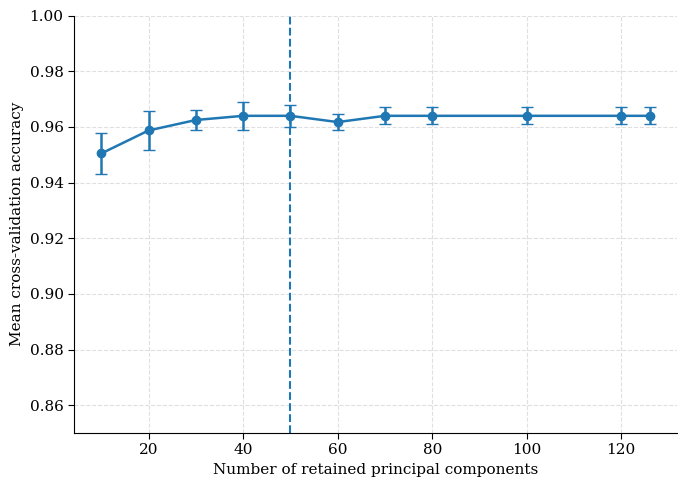

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score

# Adjust these if your variable names are different
# X_train, X_test, y_train, y_test must already be defined

n_components_list = [10, 20, 30, 40, 50, 60, 70, 80, 100, 120, 126]

param_grid = {
    "pca__n_components": n_components_list,
    "svc__C": [0.1, 1, 10, 50, 100],
    "svc__gamma": [0.001, 0.01, 0.1, "scale"]
}

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=42)),
    ("svc", SVC(kernel="rbf", class_weight="balanced", random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train)

results = pd.DataFrame(grid.cv_results_)

# Take the best C and gamma for each n_components
summary_rows = []
for n in n_components_list:
    sub = results[results["param_pca__n_components"] == n]
    best_idx = sub["mean_test_score"].idxmax()
    row = sub.loc[best_idx]

    summary_rows.append({
        "n_components": n,
        "best_C": row["param_svc__C"],
        "best_gamma": row["param_svc__gamma"],
        "mean_cv_accuracy": row["mean_test_score"],
        "std_cv_accuracy": row["std_test_score"]
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df)

# Plot mean CV accuracy vs number of PCs
plt.figure(figsize=(7, 5))
plt.errorbar(
    summary_df["n_components"],
    summary_df["mean_cv_accuracy"],
    yerr=summary_df["std_cv_accuracy"],
    marker="o",
    capsize=4,
    linewidth=1.8
)

plt.axvline(50, linestyle="--", linewidth=1.5)
plt.xlabel("Number of retained principal components")
plt.ylabel("Mean cross-validation accuracy")
plt.ylim(0.85, 1.00)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("cv_accuracy_vs_number_of_pcs.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
# ============================================================
# Completion message
# ============================================================

print("\nAll processes completed.")
print("Main outputs are saved in:")
print(" -", OUTPUT_DIR)
print(" -", MODEL_DIR)
print(" -", FEATURE_DIR)


All processes completed.
Main outputs are saved in:
 - results
 - models
 - features
